# Skin Lesion Triage

**AUTHOR**  
Rodrigo Kang

## Overview

This notebook develops a PyTorch binary image-classification workflow using the HAM10000 / ISIC 2018 Task 3 training data. The objective is to assess whether dermoscopic images can support experimental prioritisation for specialist dermatological review.

The source dataset contains seven diagnostic categories. For this project, `mel`, `bcc`, and `akiec` are grouped as lesions for priority review, while `nv`, `bkl`, `df`, and `vasc` form the lower-priority group. This binary target is a project-specific modelling choice. It is not an original dataset label, a clinically validated referral rule, an autonomous diagnostic system, or a substitute for dermatologist assessment.

HAM10000 combines images from multiple sources and uses several ground-truth procedures, including histopathology, follow-up, expert consensus, and confocal microscopy. Some lesions have multiple images, so data splitting must be performed at lesion level rather than image level. The dataset is also imbalanced and varies in acquisition conditions. Results therefore describe performance within this controlled study and should not be interpreted as evidence of clinical validity or external generalisation.

## Setup and Reproducibility

This section defines the notebook configuration, binary target, relative paths, output folders, reproducibility controls, and environment checks. It does not load the full metadata, inspect the image archive, create data splits, or train a model.

### Imports

Only the libraries required for setup are imported here. Additional dependencies are introduced in the sections where they are first used.

In [1]:
from __future__ import annotations

import os
import platform
import random
import sys
from pathlib import Path
from typing import Mapping

import numpy as np
import torch
import torchvision

### Central Configuration

Configuration values are kept in one place so that later sections use the same seed, paths, target mapping, and output locations. All executable paths are relative to the `python/` notebook directory.

In [2]:
project_name = "skin-lesion-triage"
random_seed = 42

image_archive_path = Path("../data/ISIC-images.zip")
metadata_path = Path("../data/challenge-2018-task-3-training_metadata_2026-06-20.csv")

output_root = Path("output")
output_directories = {
    "figures": output_root / "figures",
    "tables": output_root / "tables",
    "models": output_root / "models",
    "metadata": output_root / "metadata",
}

source_paths = {
    "image_archive": image_archive_path,
    "metadata": metadata_path,
}

train_fraction = 0.70
validation_fraction = 0.15
test_fraction = 0.15
image_size = 224
batch_size = 32
num_workers = 0

assert np.isclose(train_fraction + validation_fraction + test_fraction, 1.0)

### Binary Target Definition

The seven source diagnosis labels remain separate from the derived binary target. A positive model output represents the project-defined `priority dermatological review` group. It should not be interpreted as a diagnosis or as evidence of clinical urgency for an individual lesion.

In [3]:
priority_review_labels = {"mel", "bcc", "akiec"}
lower_priority_labels = {"nv", "bkl", "df", "vasc"}

binary_class_names = {
    0: "lower-priority lesion",
    1: "priority dermatological review",
}

diagnosis_to_binary_target = {
    **{label: 1 for label in priority_review_labels},
    **{label: 0 for label in lower_priority_labels},
}

expected_source_labels = priority_review_labels | lower_priority_labels

assert priority_review_labels.isdisjoint(lower_priority_labels)
assert len(expected_source_labels) == 7
assert set(diagnosis_to_binary_target) == expected_source_labels
assert set(diagnosis_to_binary_target.values()) == {0, 1}

### Setup Helpers

These helpers create the output folders, apply reproducibility settings, and confirm that the configured source files are available.

In [4]:
def create_output_directories(directories: Mapping[str, Path]) -> None:
    """
    Create the configured local output directories when they do not exist.

    Input:
    ------
    directories : Mapping[str, Path]
        Named output directory paths to create.

    Outputs:
    --------
    None
        The directories are created on the local file system.

    Author:
    -------
    Rodrigo Kang
    """
    for directory in directories.values():
        directory.mkdir(parents=True, exist_ok=True)

def configure_reproducibility(seed: int) -> None:
    """
    Configure fixed random seeds and deterministic PyTorch behaviour where practical.

    Input:
    ------
    seed : int
        Seed applied to Python, NumPy, and PyTorch random number generators.

    Outputs:
    --------
    None
        Reproducibility settings are applied to the active Python process.

    Author:
    -------
    Rodrigo Kang
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)

def validate_source_paths(paths: Mapping[str, Path]) -> dict[str, bool]:
    """
    Check that each configured source path exists and points to a file.

    Input:
    ------
    paths : Mapping[str, Path]
        Named source file paths to validate.

    Outputs:
    --------
    validation_results : dict[str, bool]
        Boolean file-status result for each configured source path.

    Author:
    -------
    Rodrigo Kang
    """
    validation_results = {
        name: path.exists() and path.is_file()
        for name, path in paths.items()
    }

    missing_paths = [
        str(paths[name])
        for name, is_valid in validation_results.items()
        if not is_valid
    ]
    if missing_paths:
        missing_list = "\n- ".join(missing_paths)
        raise FileNotFoundError(
            "Required source files were not found at the configured relative paths:"
            f"\n- {missing_list}"
        )

    return validation_results

### Initialisation and Environment

The initialisation cell creates the output structure, applies reproducibility controls, selects the available compute device, reports key package versions, and checks that the configured files are present. Exact bitwise reproducibility may still vary across hardware, operating systems, drivers, and library versions.

In [5]:
create_output_directories(output_directories)
configure_reproducibility(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
source_path_status = validate_source_paths(source_paths)

environment_summary = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy": np.__version__,
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "cuda_available": torch.cuda.is_available(),
    "selected_device": str(device),
}

print("Environment")
for key, value in environment_summary.items():
    print(f"- {key}: {value}")

print("\nConfigured source files")
for name, path in source_paths.items():
    print(f"- {name}: {path} ({'found' if source_path_status[name] else 'missing'})")

print("\nOutput directories")
for name, path in output_directories.items():
    print(f"- {name}: {path}")

Environment
- python: 3.12.13
- platform: Windows-10-10.0.19045-SP0
- numpy: 2.5.1
- torch: 2.13.0+cpu
- torchvision: 0.28.0+cpu
- cuda_available: False
- selected_device: cpu

Configured source files
- image_archive: ..\data\ISIC-images.zip (found)
- metadata: ..\data\challenge-2018-task-3-training_metadata_2026-06-20.csv (found)

Output directories
- figures: output\figures
- tables: output\tables
- models: output\models
- metadata: output\metadata


## Metadata and Image Archive Audit

This section reviews the supplied metadata and compressed image archive without extracting the images. It reconstructs the source diagnosis labels, creates the project-specific binary target, checks consistency between the metadata and archive, and records the integrity findings needed before modelling. No train, validation, or test partitions are created here.

### Data Sources and Provenance

The HAM10000 training set contains dermoscopic images collected from multiple sources over an extended period. Ground truth was established through histopathology, longitudinal stability, expert consensus, or confocal microscopy. Some lesions have more than one image, including different views or magnifications, so later data partitions must be grouped by lesion rather than image.

The ISIC 2018 disease-classification challenge used the seven HAM10000 categories as a benchmark. Differences between its internal and external test results also showed that similar aggregate scores can conceal changes in performance across acquisition sources. The dataset is suitable for a controlled modelling study, but it does not establish clinical validity or generalisation to other services, devices, or patient populations.

### Audit Imports

This section adds the libraries and standard-library modules needed to inspect the metadata, read image headers directly from the ZIP archive, and save the audit outputs.

In [6]:
import json
import zipfile
from collections import Counter
from io import BytesIO

import pandas as pd
from PIL import Image, UnidentifiedImageError

### Metadata Loading and Schema Checks

The metadata is loaded once and retained in `metadata`. Required identifiers and diagnostic hierarchy fields are checked explicitly. The short HAM10000 labels are reconstructed from the supplied hierarchy rather than assumed to be present.

In [7]:
required_metadata_columns = {
    "isic_id",
    "lesion_id",
    "diagnosis_2",
    "diagnosis_3",
    "diagnosis_confirm_type",
    "age_approx",
    "sex",
    "anatom_site_1",
}

def load_metadata(csv_path: Path, required_columns: set[str]) -> pd.DataFrame:
    """
    Load metadata and verify that required columns are available.

    Input:
    ------
    csv_path : Path
        Relative path to the source metadata CSV file.
    required_columns : set[str]
        Columns required for the initial audit and target construction.

    Outputs:
    --------
    metadata_frame : pd.DataFrame
        Loaded metadata with leading and trailing column-name whitespace removed.

    Author:
    -------
    Rodrigo Kang
    """
    metadata_frame = pd.read_csv(csv_path)
    metadata_frame.columns = metadata_frame.columns.str.strip()

    missing_columns = sorted(required_columns - set(metadata_frame.columns))
    if missing_columns:
        raise ValueError(f"Required metadata columns are missing: {missing_columns}")

    return metadata_frame
    
metadata = load_metadata(metadata_path, required_metadata_columns)

print(f"Metadata rows: {len(metadata):,}")
print(f"Metadata columns: {metadata.shape[1]}")
print("Columns:")
print(metadata.columns.tolist())

Metadata rows: 10,015
Metadata columns: 17
Columns:
['isic_id', 'attribution', 'copyright_license', 'age_approx', 'anatom_site_1', 'anatom_site_2', 'anatom_site_3', 'anatom_site_special', 'concomitant_biopsy', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_confirm_type', 'image_type', 'lesion_id', 'melanocytic', 'sex']


### Source Diagnosis and Binary Target Construction

The short source labels are reconstructed from the diagnostic hierarchy. `akiec` combines records labelled as squamous cell carcinoma or solar/actinic keratosis, matching the corresponding HAM10000 challenge category. Vascular lesions are identified from `diagnosis_2` because `diagnosis_3` is not populated for those records. The original hierarchy is retained for later subgroup analysis.

In [8]:
diagnosis_3_to_source_label = {
    "Nevus": "nv",
    "Melanoma, NOS": "mel",
    "Pigmented benign keratosis": "bkl",
    "Basal cell carcinoma": "bcc",
    "Squamous cell carcinoma, NOS": "akiec",
    "Solar or actinic keratosis": "akiec",
    "Dermatofibroma": "df",
}
vascular_diagnosis_2 = "Benign soft tissue proliferations - Vascular"

def derive_source_diagnosis(metadata_frame: pd.DataFrame) -> pd.Series:
    """
    Reconstruct the seven HAM10000 source labels from the diagnosis hierarchy.

    Input:
    ------
    metadata_frame : pd.DataFrame
        Metadata containing `diagnosis_2` and `diagnosis_3` fields.

    Outputs:
    --------
    source_diagnosis : pd.Series
        Seven-class source diagnosis label for each metadata row.

    Author:
    -------
    Rodrigo Kang
    """
    source_diagnosis = metadata_frame["diagnosis_3"].map(diagnosis_3_to_source_label)
    vascular_mask = metadata_frame["diagnosis_2"].eq(vascular_diagnosis_2)
    source_diagnosis = source_diagnosis.mask(vascular_mask, "vasc")
    return source_diagnosis

metadata = metadata.copy()
metadata["source_diagnosis"] = derive_source_diagnosis(metadata)
metadata["binary_target"] = metadata["source_diagnosis"].map(diagnosis_to_binary_target)

observed_source_labels = set(metadata["source_diagnosis"].dropna().unique())
unexpected_source_labels = observed_source_labels - expected_source_labels
missing_expected_labels = expected_source_labels - observed_source_labels

assert not unexpected_source_labels, unexpected_source_labels
assert not missing_expected_labels, missing_expected_labels
assert metadata["source_diagnosis"].notna().all()
assert metadata["binary_target"].notna().all()
assert set(metadata["binary_target"].unique()) == {0, 1}

metadata["binary_target"] = metadata["binary_target"].astype("int64")

source_diagnosis_counts = (
    metadata["source_diagnosis"]
    .value_counts()
    .rename_axis("source_diagnosis")
    .reset_index(name="image_count")
)
binary_target_counts = (
    metadata["binary_target"]
    .value_counts()
    .sort_index()
    .rename_axis("binary_target")
    .reset_index(name="image_count")
)
binary_target_counts["class_name"] = binary_target_counts["binary_target"].map(binary_class_names)
binary_target_counts["proportion"] = binary_target_counts["image_count"] / len(metadata)

print("Source diagnosis counts")
print(source_diagnosis_counts.to_string(index=False))
print()
print("Derived binary target counts")
print(binary_target_counts.to_string(index=False))

Source diagnosis counts
source_diagnosis  image_count
              nv         6705
             mel         1113
             bkl         1099
             bcc          514
           akiec          327
            vasc          142
              df          115

Derived binary target counts
 binary_target  image_count                     class_name  proportion
             0         8061          lower-priority lesion    0.804893
             1         1954 priority dermatological review    0.195107


### Metadata Integrity Audit

The metadata audit checks duplicate rows, image identifier uniqueness, lesion multiplicity, missing values, and available provenance fields. At this stage, the counts are descriptive: no records are removed and no values are imputed.

In [9]:
duplicate_row_count = int(metadata.duplicated().sum())
duplicate_image_id_count = int(metadata["isic_id"].duplicated().sum())
missing_lesion_id_count = int(metadata["lesion_id"].isna().sum())

images_per_lesion = metadata.groupby("lesion_id", dropna=False).size()
lesion_count = int(images_per_lesion.size)
lesions_with_multiple_images = int((images_per_lesion > 1).sum())
images_from_repeated_lesions = int(images_per_lesion[images_per_lesion > 1].sum())
maximum_images_per_lesion = int(images_per_lesion.max())

missing_value_summary = (
    metadata.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_proportion=lambda frame: frame["missing_count"] / len(metadata))
    .query("missing_count > 0")
    .sort_values(["missing_count", "missing_proportion"], ascending=False)
    .reset_index(names="column")
)

confirmation_counts = (
    metadata["diagnosis_confirm_type"]
    .value_counts(dropna=False)
    .rename_axis("diagnosis_confirm_type")
    .reset_index(name="image_count")
)

metadata_integrity_summary = pd.DataFrame(
    {
        "measure": [
            "metadata_rows",
            "metadata_columns",
            "unique_image_ids",
            "duplicate_rows",
            "duplicate_image_ids",
            "unique_lesions",
            "missing_lesion_ids",
            "lesions_with_multiple_images",
            "images_from_repeated_lesions",
            "maximum_images_per_lesion",
        ],
        "value": [
            len(metadata),
            metadata.shape[1],
            metadata["isic_id"].nunique(),
            duplicate_row_count,
            duplicate_image_id_count,
            lesion_count,
            missing_lesion_id_count,
            lesions_with_multiple_images,
            images_from_repeated_lesions,
            maximum_images_per_lesion,
        ],
    }
)

print(metadata_integrity_summary.to_string(index=False))
print()
print("Ground-truth confirmation counts")
print(confirmation_counts.to_string(index=False))
print()
print("Columns with missing values")
print(missing_value_summary.to_string(index=False))

                     measure  value
               metadata_rows  10015
            metadata_columns     19
            unique_image_ids  10015
              duplicate_rows      0
         duplicate_image_ids      0
              unique_lesions   7470
          missing_lesion_ids      0
lesions_with_multiple_images   1956
images_from_repeated_lesions   4501
   maximum_images_per_lesion      6

Ground-truth confirmation counts
                       diagnosis_confirm_type  image_count
                               histopathology         5340
             serial imaging showing no change         3704
                single image expert consensus          902
confocal microscopy with consensus dermoscopy           69

Columns with missing values
             column  missing_count  missing_proportion
anatom_site_special           9551            0.953669
      anatom_site_3           7657            0.764553
      anatom_site_2           4840            0.483275
      anatom_site_1       

### Compressed Image Archive Audit

Images are inspected directly inside the ZIP archive to avoid extraction and duplicate local storage. The audit matches image identifiers to the metadata and reads enough of each file to record its format, dimensions, and colour mode, while also identifying unreadable members. Licence and attribution files remain in the archive but are excluded from image counts.

In [10]:
supported_image_extensions = {".jpg", ".jpeg", ".png"}

def audit_image_archive(archive_path: Path) -> tuple[pd.DataFrame, list[str]]:
    """
    Inspect image members in a ZIP archive without extracting them.

    Input:
    ------
    archive_path : Path
        Relative path to the compressed image archive.

    Outputs:
    --------
    image_audit : pd.DataFrame
        One row per image member with identifier, format, dimensions, mode and read status.
    non_image_members : list[str]
        Archive members excluded from the image audit because they are not image files.

    Author:
    -------
    Rodrigo Kang
    """
    audit_records = []
    non_image_members = []

    with zipfile.ZipFile(archive_path) as archive:
        for member in archive.infolist():
            if member.is_dir():
                continue

            member_path = Path(member.filename)
            if member_path.suffix.lower() not in supported_image_extensions:
                non_image_members.append(member.filename)
                continue

            record = {
                "archive_member": member.filename,
                "isic_id": member_path.stem,
                "extension": member_path.suffix.lower(),
                "file_size_bytes": member.file_size,
                "image_format": None,
                "width": None,
                "height": None,
                "mode": None,
                "readable": False,
                "error": None,
            }

            try:
                with archive.open(member) as image_file:
                    image_bytes = image_file.read()
                with Image.open(BytesIO(image_bytes)) as image:
                    image.load()
                    record.update(
                        {
                            "image_format": image.format,
                            "width": image.width,
                            "height": image.height,
                            "mode": image.mode,
                            "readable": True,
                        }
                    )
            except (OSError, ValueError, UnidentifiedImageError) as error:
                record["error"] = str(error)

            audit_records.append(record)

    return pd.DataFrame(audit_records), sorted(non_image_members)

image_audit, non_image_archive_members = audit_image_archive(image_archive_path)

metadata_image_ids = set(metadata["isic_id"])
archive_image_ids = set(image_audit["isic_id"])
metadata_rows_without_images = sorted(metadata_image_ids - archive_image_ids)
archive_images_without_metadata = sorted(archive_image_ids - metadata_image_ids)

image_dimension_counts = (
    image_audit.groupby(["width", "height"], dropna=False)
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count", ascending=False)
)
image_mode_counts = (
    image_audit["mode"]
    .value_counts(dropna=False)
    .rename_axis("mode")
    .reset_index(name="image_count")
)
image_format_counts = (
    image_audit["image_format"]
    .value_counts(dropna=False)
    .rename_axis("image_format")
    .reset_index(name="image_count")
)

archive_integrity_summary = pd.DataFrame(
    {
        "measure": [
            "archive_image_members",
            "unique_archive_image_ids",
            "unreadable_images",
            "metadata_rows_without_images",
            "archive_images_without_metadata",
            "non_image_archive_members",
        ],
        "value": [
            len(image_audit),
            image_audit["isic_id"].nunique(),
            int((~image_audit["readable"]).sum()),
            len(metadata_rows_without_images),
            len(archive_images_without_metadata),
            len(non_image_archive_members),
        ],
    }
)

print(archive_integrity_summary.to_string(index=False))
print()
print("Image formats")
print(image_format_counts.to_string(index=False))
print()
print("Image modes")
print(image_mode_counts.to_string(index=False))
print()
print("Image dimensions")
print(image_dimension_counts.to_string(index=False))
print()
print("Non-image archive members")
for member_name in non_image_archive_members:
    print(f"- {member_name}")

                        measure  value
          archive_image_members  10015
       unique_archive_image_ids  10015
              unreadable_images      0
   metadata_rows_without_images      0
archive_images_without_metadata      0
      non_image_archive_members      3

Image formats
image_format  image_count
        JPEG        10015

Image modes
mode  image_count
 RGB        10015

Image dimensions
 width  height  image_count
   600     450        10015

Non-image archive members
- attribution.txt
- licenses/CC-BY-NC.txt
- metadata.csv


### Audit Artefacts and Findings

Compact CSV and JSON outputs are saved for traceability. The derived target is stored alongside the original diagnostic hierarchy, while the per-image archive audit records file integrity and image properties. These outputs support later split construction without changing the source data.

In [11]:
target_definition = {
    "project_name": project_name,
    "target_name": "binary_target",
    "positive_class_index": 1,
    "positive_class_name": binary_class_names[1],
    "positive_source_labels": sorted(priority_review_labels),
    "negative_class_index": 0,
    "negative_class_name": binary_class_names[0],
    "negative_source_labels": sorted(lower_priority_labels),
    "source_label_column": "source_diagnosis",
    "statement": (
        "Project-specific analytical grouping for experimental prioritisation; "
        "not an original dataset ground truth or clinically validated referral rule."
    ),
}

metadata_audit_path = output_directories["tables"] / "metadata-with-derived-target.csv"
source_counts_path = output_directories["tables"] / "source-diagnosis-counts.csv"
binary_counts_path = output_directories["tables"] / "binary-target-counts.csv"
missing_values_path = output_directories["tables"] / "missing-value-summary.csv"
confirmation_counts_path = output_directories["tables"] / "ground-truth-confirmation-counts.csv"
image_audit_path = output_directories["tables"] / "image-archive-audit.csv"
audit_summary_path = output_directories["metadata"] / "data-audit-summary.json"
target_definition_path = output_directories["metadata"] / "binary-target-definition.json"

metadata.to_csv(metadata_audit_path, index=False)
source_diagnosis_counts.to_csv(source_counts_path, index=False)
binary_target_counts.to_csv(binary_counts_path, index=False)
missing_value_summary.to_csv(missing_values_path, index=False)
confirmation_counts.to_csv(confirmation_counts_path, index=False)
image_audit.to_csv(image_audit_path, index=False)

audit_summary = {
    "metadata": dict(zip(metadata_integrity_summary["measure"], metadata_integrity_summary["value"].astype(int))),
    "archive": dict(zip(archive_integrity_summary["measure"], archive_integrity_summary["value"].astype(int))),
    "source_diagnosis_counts": dict(zip(source_diagnosis_counts["source_diagnosis"], source_diagnosis_counts["image_count"].astype(int))),
    "binary_target_counts": dict(zip(binary_target_counts["binary_target"].astype(str), binary_target_counts["image_count"].astype(int))),
    "metadata_rows_without_images": metadata_rows_without_images,
    "archive_images_without_metadata": archive_images_without_metadata,
    "non_image_archive_members": non_image_archive_members,
}

with audit_summary_path.open("w", encoding="utf-8") as file:
    json.dump(audit_summary, file, indent=2)
with target_definition_path.open("w", encoding="utf-8") as file:
    json.dump(target_definition, file, indent=2)

print("Saved audit artefacts")
for artefact_path in [
    metadata_audit_path,
    source_counts_path,
    binary_counts_path,
    missing_values_path,
    confirmation_counts_path,
    image_audit_path,
    audit_summary_path,
    target_definition_path,
]:
    print(f"- {artefact_path}")

Saved audit artefacts
- output\tables\metadata-with-derived-target.csv
- output\tables\source-diagnosis-counts.csv
- output\tables\binary-target-counts.csv
- output\tables\missing-value-summary.csv
- output\tables\ground-truth-confirmation-counts.csv
- output\tables\image-archive-audit.csv
- output\metadata\data-audit-summary.json
- output\metadata\binary-target-definition.json


The audit confirms whether the metadata and image archive are internally aligned and identifies the structural issues relevant to modelling. Multiple images linked to the same lesion confirm that the next partitioning step must group records by `lesion_id`.

The binary target remains an analytical grouping. It combines three source categories for prioritised review without replacing the original diagnosis labels or implying that the grouped conditions share the same clinical urgency.

## Exploratory Analysis

This section describes the dataset before the lesion-aware split is created. Image counts and lesion counts are reported separately because repeated photographs of the same lesion are not independent observations. The review also covers demographic and anatomical metadata, ground-truth confirmation, lesion multiplicity, and a small reproducible image sample.

The analysis is descriptive. It characterises the supplied dataset and the project-specific binary target, but it does not estimate population prevalence, define clinical difficulty, or establish a referral policy.

### Exploratory Imports and Plot Configuration

Matplotlib is added for static figures. The analysis uses the audited `metadata`, `image_audit`, and compressed image archive prepared in the previous section.

In [12]:
import matplotlib.pyplot as plt

figure_dpi = 120
plt.rcParams["figure.dpi"] = figure_dpi
plt.rcParams["axes.titleweight"] = "normal"
plt.rcParams["axes.grid"] = False

### Exploratory Helpers

These helpers provide consistent figure saving and allow selected images to be read directly from the ZIP archive without extraction.

In [13]:
def save_current_figure(file_name: str) -> Path:
    """
    Save the active Matplotlib figure to the configured figures directory.

    Input:
    ------
    file_name : str
        Concise kebab-case PNG filename for the figure.

    Outputs:
    --------
    figure_path : Path
        Path to the saved figure file.

    Author:
    -------
    Rodrigo Kang
    """
    figure_path = output_directories["figures"] / file_name
    plt.savefig(figure_path, bbox_inches="tight")
    return figure_path

def load_archive_image(archive_path: Path, archive_member: str) -> Image.Image:
    """
    Load one RGB image from the compressed archive without extracting it.

    Input:
    ------
    archive_path : Path
        Relative path to the compressed image archive.
    archive_member : str
        Exact member name of the image inside the archive.

    Outputs:
    --------
    image : Image.Image
        Independent RGB copy of the selected image.

    Author:
    -------
    Rodrigo Kang
    """
    with zipfile.ZipFile(archive_path) as archive:
        with archive.open(archive_member) as image_file:
            with Image.open(BytesIO(image_file.read())) as image:
                return image.convert("RGB").copy()

### Source Diagnosis and Binary Target Distribution

Class balance is reported by both image and lesion. For lesion-level summaries, one record is retained per `lesion_id`. The earlier audit confirmed that all images linked to a lesion share the same reconstructed diagnosis and binary target.

This prevents lesions with several photographs from receiving additional weight in the case-level summary.

In [14]:
lesion_label_consistency = (
    metadata.groupby("lesion_id")[["source_diagnosis", "binary_target"]]
    .nunique()
)
assert lesion_label_consistency.le(1).all().all()

lesion_metadata = (
    metadata.sort_values("isic_id")
    .drop_duplicates(subset="lesion_id", keep="first")
    .copy()
)

source_order = ["nv", "mel", "bkl", "bcc", "akiec", "vasc", "df"]
source_distribution = pd.DataFrame(
    {
        "image_count": metadata["source_diagnosis"].value_counts().reindex(source_order),
        "lesion_count": lesion_metadata["source_diagnosis"].value_counts().reindex(source_order),
    }
).fillna(0).astype(int)
source_distribution["image_proportion"] = source_distribution["image_count"] / len(metadata)
source_distribution["lesion_proportion"] = source_distribution["lesion_count"] / len(lesion_metadata)
source_distribution = source_distribution.reset_index(names="source_diagnosis")

binary_distribution = pd.DataFrame(
    {
        "image_count": metadata["binary_target"].value_counts().sort_index(),
        "lesion_count": lesion_metadata["binary_target"].value_counts().sort_index(),
    }
).astype(int)
binary_distribution["class_name"] = binary_distribution.index.map(binary_class_names)
binary_distribution["image_proportion"] = binary_distribution["image_count"] / len(metadata)
binary_distribution["lesion_proportion"] = binary_distribution["lesion_count"] / len(lesion_metadata)
binary_distribution = binary_distribution.reset_index(names="binary_target")

print("Source diagnosis distribution")
print(source_distribution.to_string(index=False))
print()
print("Binary target distribution")
print(binary_distribution.to_string(index=False))

Source diagnosis distribution
source_diagnosis  image_count  lesion_count  image_proportion  lesion_proportion
              nv         6705          5403          0.669496           0.723293
             mel         1113           614          0.111133           0.082195
             bkl         1099           727          0.109735           0.097323
             bcc          514           327          0.051323           0.043775
           akiec          327           228          0.032651           0.030522
            vasc          142            98          0.014179           0.013119
              df          115            73          0.011483           0.009772

Binary target distribution
 binary_target  image_count  lesion_count                     class_name  image_proportion  lesion_proportion
             0         8061          6301          lower-priority lesion          0.804893           0.843507
             1         1954          1169 priority dermatological review  

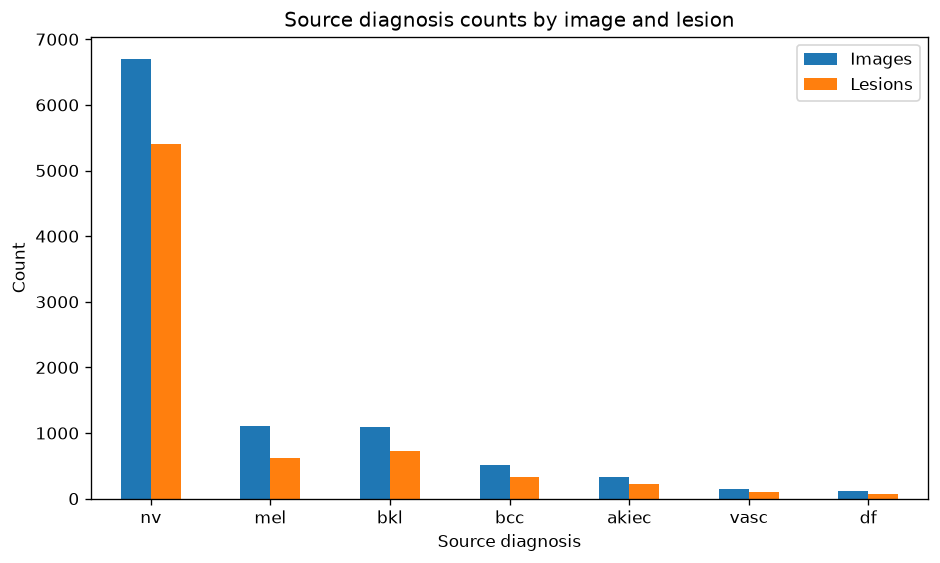

Saved: output\figures\source-diagnosis-image-lesion-counts.png


In [15]:
plot_frame = source_distribution.set_index("source_diagnosis")[["image_count", "lesion_count"]]
ax = plot_frame.plot(kind="bar", figsize=(9, 5))
ax.set_title("Source diagnosis counts by image and lesion")
ax.set_xlabel("Source diagnosis")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Images", "Lesions"])
figure_path = save_current_figure("source-diagnosis-image-lesion-counts.png")
plt.show()
print(f"Saved: {figure_path}")

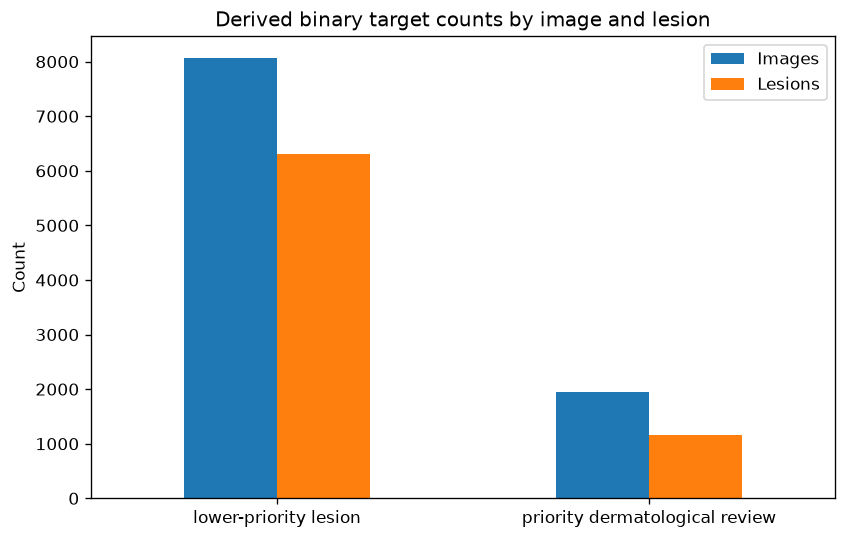

Saved: output\figures\binary-target-image-lesion-counts.png


In [16]:
plot_frame = binary_distribution.set_index("class_name")[["image_count", "lesion_count"]]
ax = plot_frame.plot(kind="bar", figsize=(8, 5))
ax.set_title("Derived binary target counts by image and lesion")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Images", "Lesions"])
figure_path = save_current_figure("binary-target-image-lesion-counts.png")
plt.show()
print(f"Saved: {figure_path}")

### Lesion Multiplicity

Some lesions have several images, which may capture different views or magnifications. They also create a clear leakage risk if images are split independently. The distribution below shows how many images are associated with each lesion before modelling.

 images_per_lesion  lesion_count  lesion_proportion
                 1          5514           0.738153
                 2          1423           0.190495
                 3           490           0.065596
                 4            34           0.004552
                 5             5           0.000669
                 6             4           0.000535


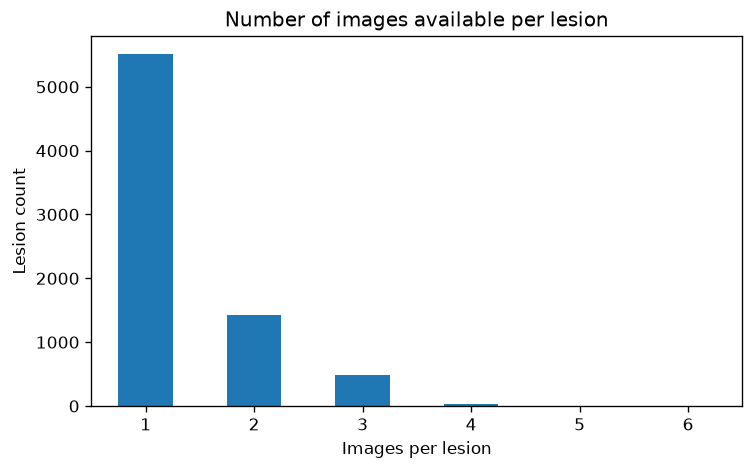

Saved: output\figures\images-per-lesion-distribution.png


In [17]:
lesion_multiplicity = (
    images_per_lesion.value_counts()
    .sort_index()
    .rename_axis("images_per_lesion")
    .reset_index(name="lesion_count")
)
lesion_multiplicity["lesion_proportion"] = lesion_multiplicity["lesion_count"] / lesion_count

print(lesion_multiplicity.to_string(index=False))

ax = lesion_multiplicity.plot(
    x="images_per_lesion",
    y="lesion_count",
    kind="bar",
    legend=False,
    figsize=(7, 4),
)
ax.set_title("Number of images available per lesion")
ax.set_xlabel("Images per lesion")
ax.set_ylabel("Lesion count")
ax.tick_params(axis="x", rotation=0)
figure_path = save_current_figure("images-per-lesion-distribution.png")
plt.show()
print(f"Saved: {figure_path}")

### Age, Sex and Anatomical Site

Age, sex, and anatomical site are summarised at lesion level so that repeated images are not counted as separate cases. These fields help describe the composition of the dataset and identify missingness or uneven representation.

Age is approximate, and the available metadata does not support conclusions about population prevalence or causal relationships.

In [18]:
age_summary = (
    lesion_metadata.groupby("binary_target")["age_approx"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)
age_summary["class_name"] = age_summary["binary_target"].map(binary_class_names)

sex_distribution = (
    lesion_metadata.assign(sex=lesion_metadata["sex"].fillna("Missing"))
    .groupby(["binary_target", "sex"])
    .size()
    .reset_index(name="lesion_count")
)
sex_distribution["class_name"] = sex_distribution["binary_target"].map(binary_class_names)

site_distribution = (
    lesion_metadata.assign(anatom_site_1=lesion_metadata["anatom_site_1"].fillna("Missing"))
    .groupby(["binary_target", "anatom_site_1"])
    .size()
    .reset_index(name="lesion_count")
)
site_totals = site_distribution.groupby("binary_target")["lesion_count"].transform("sum")
site_distribution["within_class_proportion"] = site_distribution["lesion_count"] / site_totals
site_distribution["class_name"] = site_distribution["binary_target"].map(binary_class_names)

print("Approximate age summary by binary target")
print(age_summary.to_string(index=False))
print()
print("Sex distribution by binary target")
print(sex_distribution.to_string(index=False))

Approximate age summary by binary target
 binary_target  count      mean  median       std  min  max                     class_name
             0   6229 49.544871    50.0 15.012491  5.0 85.0          lower-priority lesion
             1   1169 63.879384    65.0 14.290647  5.0 85.0 priority dermatological review

Sex distribution by binary target
 binary_target     sex  lesion_count                     class_name
             0 Missing            46          lower-priority lesion
             0  female          2977          lower-priority lesion
             0    male          3278          lower-priority lesion
             1  female           445 priority dermatological review
             1    male           724 priority dermatological review


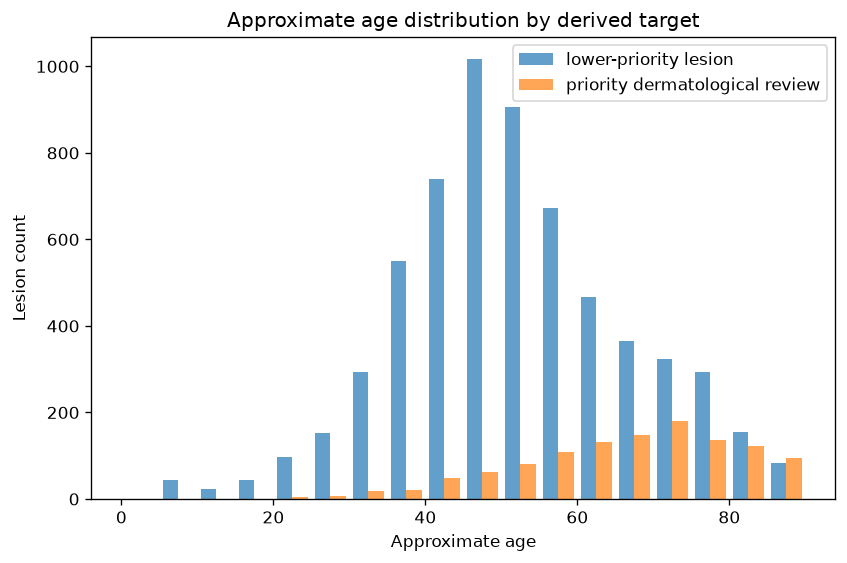

Saved: output\figures\age-distribution-by-binary-target.png


In [19]:
age_plot_data = [
    lesion_metadata.loc[lesion_metadata["binary_target"].eq(class_index), "age_approx"].dropna()
    for class_index in [0, 1]
]
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(age_plot_data, bins=np.arange(0, 95, 5), label=[binary_class_names[0], binary_class_names[1]], alpha=0.7)
ax.set_title("Approximate age distribution by derived target")
ax.set_xlabel("Approximate age")
ax.set_ylabel("Lesion count")
ax.legend()
figure_path = save_current_figure("age-distribution-by-binary-target.png")
plt.show()
print(f"Saved: {figure_path}")

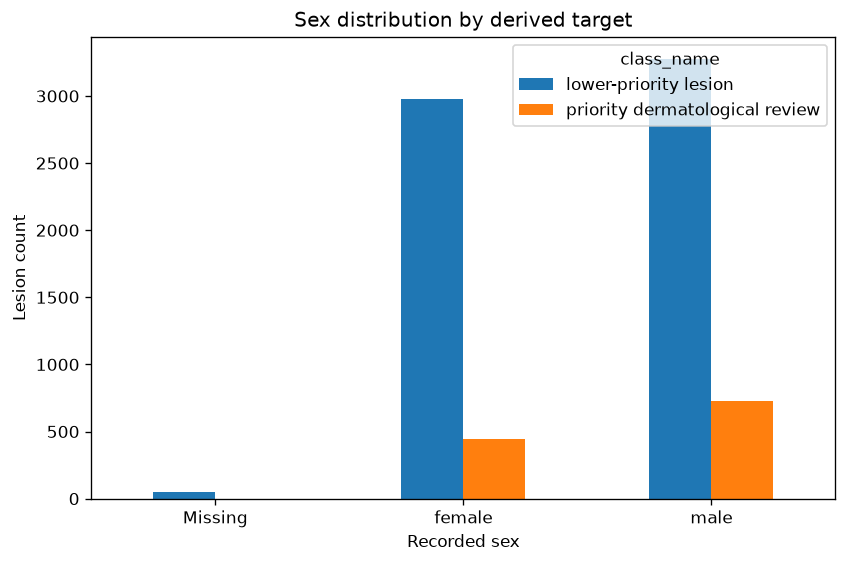

Saved: output\figures\sex-distribution-by-binary-target.png


In [20]:
sex_plot = (
    sex_distribution.pivot(index="sex", columns="class_name", values="lesion_count")
    .fillna(0)
)
ax = sex_plot.plot(kind="bar", figsize=(8, 5))
ax.set_title("Sex distribution by derived target")
ax.set_xlabel("Recorded sex")
ax.set_ylabel("Lesion count")
ax.tick_params(axis="x", rotation=0)
figure_path = save_current_figure("sex-distribution-by-binary-target.png")
plt.show()
print(f"Saved: {figure_path}")

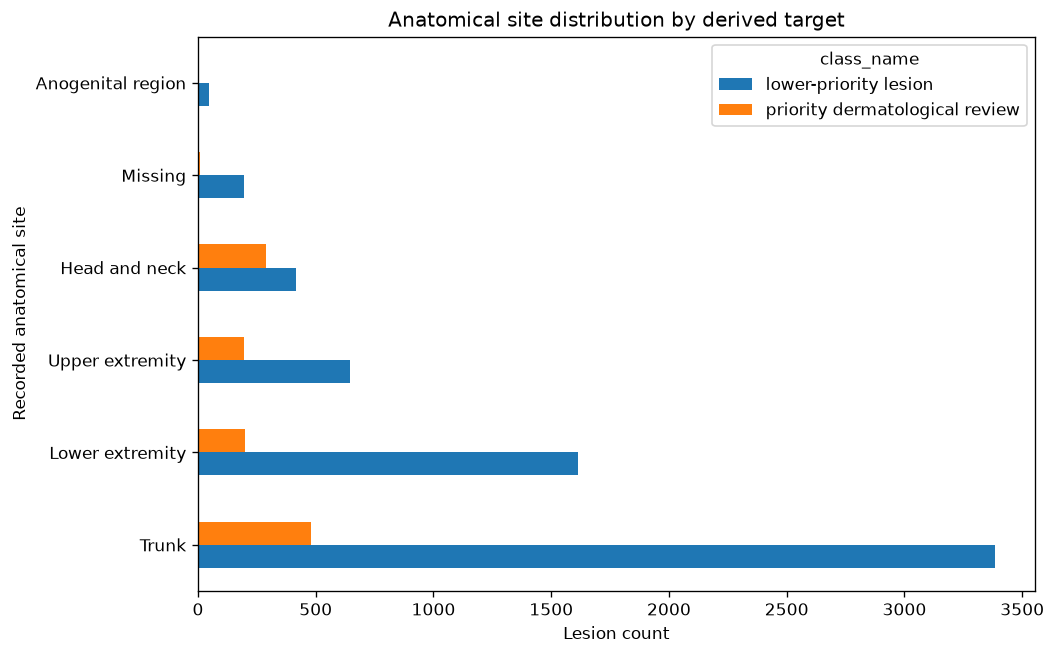

Saved: output\figures\anatomical-site-by-binary-target.png


In [21]:
site_plot = (
    site_distribution.pivot(index="anatom_site_1", columns="class_name", values="lesion_count")
    .fillna(0)
    .sort_values(by=list(binary_class_names.values()), ascending=False)
)
ax = site_plot.plot(kind="barh", figsize=(9, 6))
ax.set_title("Anatomical site distribution by derived target")
ax.set_xlabel("Lesion count")
ax.set_ylabel("Recorded anatomical site")
figure_path = save_current_figure("anatomical-site-by-binary-target.png")
plt.show()
print(f"Saved: {figure_path}")

### Ground-Truth Confirmation

The source diagnoses were established through several confirmation routes. Their distribution is shown by diagnosis because performance against this mixed reference standard should not be treated as equivalent to evaluation against uniform histopathology.

source_diagnosis                        diagnosis_confirm_type  image_count  within_diagnosis_proportion
           akiec                                histopathology          327                     1.000000
             bcc                                histopathology          514                     1.000000
             bkl confocal microscopy with consensus dermoscopy           69                     0.062784
             bkl                                histopathology          766                     0.696997
             bkl                 single image expert consensus          264                     0.240218
              df                                histopathology           55                     0.478261
              df                 single image expert consensus           60                     0.521739
             mel                                histopathology         1113                     1.000000
              nv                                histopa

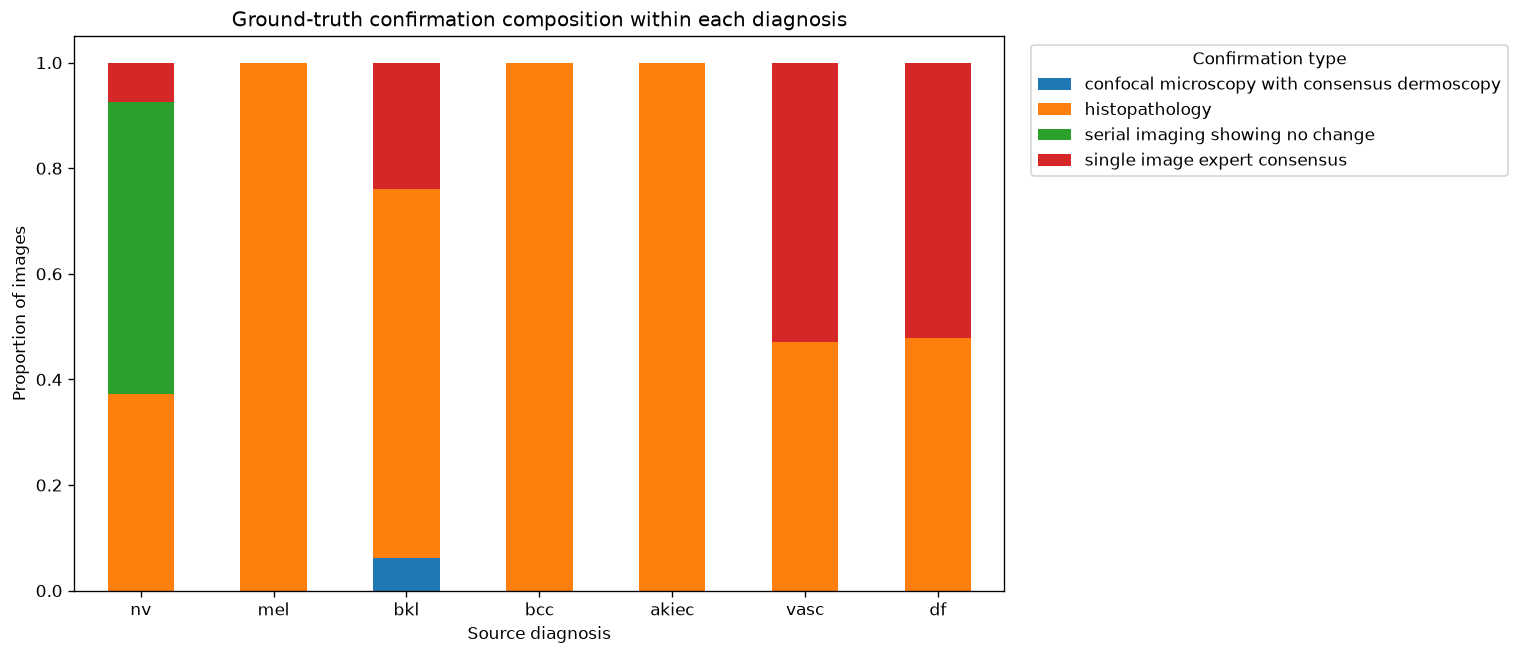

Saved: output\figures\confirmation-method-by-source-diagnosis.png


In [22]:
confirmation_by_diagnosis = (
    metadata.groupby(["source_diagnosis", "diagnosis_confirm_type"])
    .size()
    .reset_index(name="image_count")
)
confirmation_by_diagnosis["within_diagnosis_proportion"] = (
    confirmation_by_diagnosis["image_count"]
    / confirmation_by_diagnosis.groupby("source_diagnosis")["image_count"].transform("sum")
)

confirmation_plot = (
    confirmation_by_diagnosis.pivot(
        index="source_diagnosis",
        columns="diagnosis_confirm_type",
        values="within_diagnosis_proportion",
    )
    .fillna(0)
    .reindex(source_order)
)

print(confirmation_by_diagnosis.to_string(index=False))

ax = confirmation_plot.plot(kind="bar", stacked=True, figsize=(10, 6))
ax.set_title("Ground-truth confirmation composition within each diagnosis")
ax.set_xlabel("Source diagnosis")
ax.set_ylabel("Proportion of images")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Confirmation type", bbox_to_anchor=(1.02, 1), loc="upper left")
figure_path = save_current_figure("confirmation-method-by-source-diagnosis.png")
plt.show()
print(f"Saved: {figure_path}")

### Reproducible Image Examples

Two images are selected from each source diagnosis using the fixed project seed. The grid illustrates variation in appearance, framing, and acquisition artefacts. It is not intended to define representative examples or diagnostic cues, and it does not provide evidence of generalisation to other clinical settings.

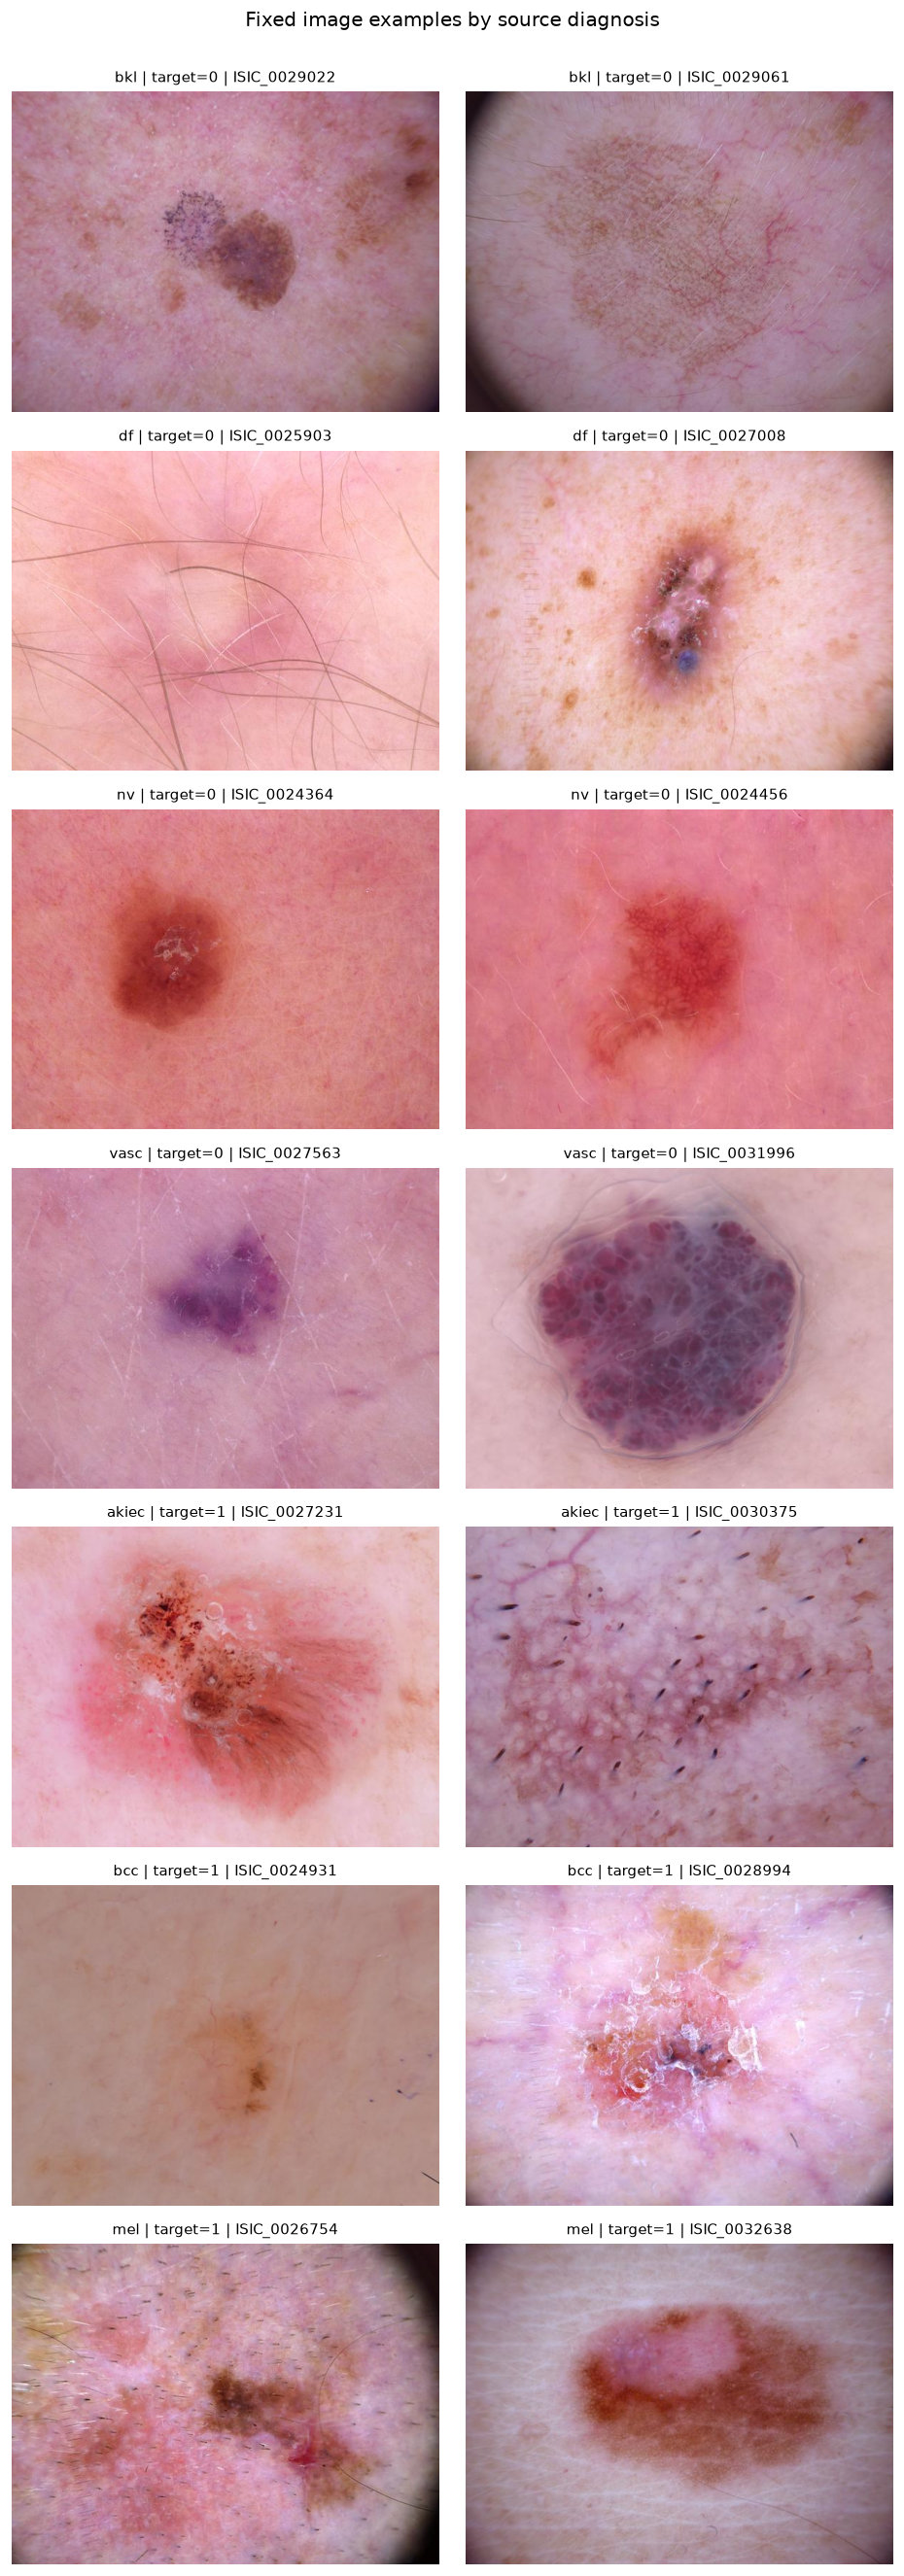

Saved: output\figures\fixed-examples-by-source-diagnosis.png


In [23]:
archive_member_lookup = image_audit.set_index("isic_id")["archive_member"].to_dict()

sampled_examples = (
    metadata.groupby("source_diagnosis", group_keys=False)
    .sample(n=2, random_state=random_seed)
    .sort_values(["binary_target", "source_diagnosis", "isic_id"])
    .reset_index(drop=True)
)

fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(8, 22))
for axis, row in zip(axes.flat, sampled_examples.itertuples(index=False)):
    image = load_archive_image(image_archive_path, archive_member_lookup[row.isic_id])
    axis.imshow(image)
    axis.set_title(
        f"{row.source_diagnosis} | target={row.binary_target} | {row.isic_id}",
        fontsize=9,
    )
    axis.axis("off")

fig.suptitle("Fixed image examples by source diagnosis", y=1.002)
fig.tight_layout()
figure_path = save_current_figure("fixed-examples-by-source-diagnosis.png")
plt.show()
print(f"Saved: {figure_path}")

### Exploratory Artefacts and Interpretation

The summary tables retain the image-level and lesion-level distributions used in the figures. Three findings are particularly relevant for the modelling workflow:

- class imbalance remains substantial at lesion level;
- confirmation methods differ across diagnoses;
- repeated images require lesion-aware partitioning.

The demographic and anatomical distributions describe this dataset only and should not be interpreted as clinical prevalence.

In [24]:
source_distribution_path = output_directories["tables"] / "source-diagnosis-image-lesion-distribution.csv"
binary_distribution_path = output_directories["tables"] / "binary-target-image-lesion-distribution.csv"
lesion_multiplicity_path = output_directories["tables"] / "lesion-multiplicity-distribution.csv"
age_summary_path = output_directories["tables"] / "age-summary-by-binary-target.csv"
sex_distribution_path = output_directories["tables"] / "sex-distribution-by-binary-target.csv"
site_distribution_path = output_directories["tables"] / "anatomical-site-by-binary-target.csv"
confirmation_distribution_path = output_directories["tables"] / "confirmation-method-by-source-diagnosis.csv"
sampled_examples_path = output_directories["tables"] / "fixed-image-examples.csv"

source_distribution.to_csv(source_distribution_path, index=False)
binary_distribution.to_csv(binary_distribution_path, index=False)
lesion_multiplicity.to_csv(lesion_multiplicity_path, index=False)
age_summary.to_csv(age_summary_path, index=False)
sex_distribution.to_csv(sex_distribution_path, index=False)
site_distribution.to_csv(site_distribution_path, index=False)
confirmation_by_diagnosis.to_csv(confirmation_distribution_path, index=False)
sampled_examples[["isic_id", "lesion_id", "source_diagnosis", "binary_target"]].to_csv(
    sampled_examples_path,
    index=False,
)

print("Saved exploratory artefacts")
for artefact_path in [
    source_distribution_path,
    binary_distribution_path,
    lesion_multiplicity_path,
    age_summary_path,
    sex_distribution_path,
    site_distribution_path,
    confirmation_distribution_path,
    sampled_examples_path,
]:
    print(f"- {artefact_path}")

Saved exploratory artefacts
- output\tables\source-diagnosis-image-lesion-distribution.csv
- output\tables\binary-target-image-lesion-distribution.csv
- output\tables\lesion-multiplicity-distribution.csv
- output\tables\age-summary-by-binary-target.csv
- output\tables\sex-distribution-by-binary-target.csv
- output\tables\anatomical-site-by-binary-target.csv
- output\tables\confirmation-method-by-source-diagnosis.csv
- output\tables\fixed-image-examples.csv


## Lesion-Aware Data Preparation

This section creates reproducible train, validation, and test partitions at lesion level. All images linked to the same `lesion_id` remain in one partition, preventing repeated views of a lesion from crossing evaluation boundaries. The split is approximately stratified by the project-specific binary target and saved before modelling begins.

It then defines train-only normalisation statistics, image transformations, a ZIP-backed PyTorch dataset, and the initial data loaders. These steps prepare the modelling pipeline without changing the source data or implying clinical validation.

### Data Preparation Imports

PyTorch, torchvision, and scikit-learn components required for splitting, transformation, and data loading are introduced here.

In [25]:
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.model_selection import train_test_split

### Lesion-Aware Split

The split is created from one row per lesion and then joined back to all associated images. Stratifying at lesion level preserves the approximate positive-class balance without treating repeated photographs as independent cases. The fixed project seed makes the assignment reproducible.

In [26]:
split_columns = [
    "lesion_id",
    "source_diagnosis",
    "binary_target",
]
lesion_split_frame = (
    metadata.sort_values("isic_id")
    .drop_duplicates(subset="lesion_id", keep="first")
    [split_columns]
    .reset_index(drop=True)
)

train_lesions, remaining_lesions = train_test_split(
    lesion_split_frame,
    test_size=validation_fraction + test_fraction,
    stratify=lesion_split_frame["binary_target"],
    random_state=random_seed,
)

relative_test_fraction = test_fraction / (validation_fraction + test_fraction)
validation_lesions, test_lesions = train_test_split(
    remaining_lesions,
    test_size=relative_test_fraction,
    stratify=remaining_lesions["binary_target"],
    random_state=random_seed,
)

train_lesions = train_lesions.assign(split="train")
validation_lesions = validation_lesions.assign(split="validation")
test_lesions = test_lesions.assign(split="test")

lesion_splits = pd.concat(
    [train_lesions, validation_lesions, test_lesions],
    ignore_index=True,
).sort_values(["split", "lesion_id"]).reset_index(drop=True)

image_splits = (
    metadata.merge(
        lesion_splits[["lesion_id", "split"]],
        on="lesion_id",
        how="left",
        validate="many_to_one",
    )
    .sort_values(["split", "lesion_id", "isic_id"])
    .reset_index(drop=True)
)

assert lesion_splits["lesion_id"].is_unique
assert image_splits["split"].notna().all()
assert set(image_splits["split"].unique()) == {"train", "validation", "test"}

print("Lesion counts by split")
print(lesion_splits["split"].value_counts().reindex(["train", "validation", "test"]).to_string())
print("\nImage counts by split")
print(image_splits["split"].value_counts().reindex(["train", "validation", "test"]).to_string())

Lesion counts by split
split
train         5229
validation    1120
test          1121

Image counts by split
split
train         7014
validation    1506
test          1495


### Split Integrity and Distribution Checks

The checks confirm that each lesion appears in only one partition. Binary-target and source-diagnosis distributions are reported at both image and lesion level so that any differences introduced by grouped splitting remain visible.

In [27]:
split_lesion_sets = {
    split_name: set(frame["lesion_id"])
    for split_name, frame in {
        "train": train_lesions,
        "validation": validation_lesions,
        "test": test_lesions,
    }.items()
}

assert split_lesion_sets["train"].isdisjoint(split_lesion_sets["validation"])
assert split_lesion_sets["train"].isdisjoint(split_lesion_sets["test"])
assert split_lesion_sets["validation"].isdisjoint(split_lesion_sets["test"])
assert set().union(*split_lesion_sets.values()) == set(lesion_split_frame["lesion_id"])

split_summary = (
    image_splits.groupby("split")
    .agg(
        image_count=("isic_id", "size"),
        lesion_count=("lesion_id", "nunique"),
        positive_image_count=("binary_target", "sum"),
    )
    .reindex(["train", "validation", "test"])
)
split_summary["positive_image_proportion"] = (
    split_summary["positive_image_count"] / split_summary["image_count"]
)

lesion_target_distribution = (
    lesion_splits.groupby(["split", "binary_target"])
    .size()
    .rename("lesion_count")
    .reset_index()
)
lesion_target_distribution["class_name"] = lesion_target_distribution["binary_target"].map(binary_class_names)

image_target_distribution = (
    image_splits.groupby(["split", "binary_target"])
    .size()
    .rename("image_count")
    .reset_index()
)
image_target_distribution["class_name"] = image_target_distribution["binary_target"].map(binary_class_names)

source_diagnosis_split_distribution = (
    image_splits.groupby(["split", "source_diagnosis"])
    .agg(image_count=("isic_id", "size"), lesion_count=("lesion_id", "nunique"))
    .reset_index()
)

print("Split summary")
print(split_summary.to_string())
print("\nBinary target by lesion")
print(lesion_target_distribution.to_string(index=False))
print("\nSource diagnosis by split")
print(source_diagnosis_split_distribution.to_string(index=False))

Split summary
            image_count  lesion_count  positive_image_count  positive_image_proportion
split                                                                                 
train              7014          5229                  1372                   0.195609
validation         1506          1120                   299                   0.198539
test               1495          1121                   283                   0.189298

Binary target by lesion
     split  binary_target  lesion_count                     class_name
      test              0           945          lower-priority lesion
      test              1           176 priority dermatological review
     train              0          4411          lower-priority lesion
     train              1           818 priority dermatological review
validation              0           945          lower-priority lesion
validation              1           175 priority dermatological review

Source diagnosis by split
  

### Split Persistence

Image-level and lesion-level assignments are saved separately. Persisting the exact identifiers ensures that later model comparisons use the same partitions.

In [28]:
split_file_paths = {}
for split_name in ["train", "validation", "test"]:
    image_path = output_directories["metadata"] / f"{split_name}-images.csv"
    lesion_path = output_directories["metadata"] / f"{split_name}-lesions.csv"

    image_splits.loc[image_splits["split"].eq(split_name)].to_csv(image_path, index=False)
    lesion_splits.loc[lesion_splits["split"].eq(split_name)].to_csv(lesion_path, index=False)

    split_file_paths[f"{split_name}_images"] = image_path
    split_file_paths[f"{split_name}_lesions"] = lesion_path

split_summary_path = output_directories["tables"] / "data-split-summary.csv"
lesion_target_split_path = output_directories["tables"] / "lesion-target-distribution-by-split.csv"
image_target_split_path = output_directories["tables"] / "image-target-distribution-by-split.csv"
source_split_path = output_directories["tables"] / "source-diagnosis-distribution-by-split.csv"

split_summary.reset_index(names="split").to_csv(split_summary_path, index=False)
lesion_target_distribution.to_csv(lesion_target_split_path, index=False)
image_target_distribution.to_csv(image_target_split_path, index=False)
source_diagnosis_split_distribution.to_csv(source_split_path, index=False)

print("Saved split artefacts")
for artefact_path in [
    *split_file_paths.values(),
    split_summary_path,
    lesion_target_split_path,
    image_target_split_path,
    source_split_path,
]:
    print(f"- {artefact_path}")

Saved split artefacts
- output\metadata\train-images.csv
- output\metadata\train-lesions.csv
- output\metadata\validation-images.csv
- output\metadata\validation-lesions.csv
- output\metadata\test-images.csv
- output\metadata\test-lesions.csv
- output\tables\data-split-summary.csv
- output\tables\lesion-target-distribution-by-split.csv
- output\tables\image-target-distribution-by-split.csv
- output\tables\source-diagnosis-distribution-by-split.csv


### Train-Only Normalisation Statistics

Channel means and standard deviations are estimated after resizing and from training images only. Validation and test data are excluded from these preprocessing estimates. Images are read directly from the archive without augmentation.

In [29]:
normalisation_resize_transform = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
    ]
)

def calculate_channel_statistics(
    split_frame: pd.DataFrame,
    archive_path: Path,
    member_lookup: Mapping[str, str],
    image_transform: transforms.Compose,
) -> tuple[list[float], list[float]]:
    """
    Calculate RGB channel means and standard deviations for one image split.

    Input:
    ------
    split_frame : pd.DataFrame
        Image-level records used to estimate channel statistics.
    archive_path : Path
        Relative path to the compressed image archive.
    member_lookup : Mapping[str, str]
        Mapping from image identifiers to exact archive member names.
    image_transform : transforms.Compose
        Deterministic resize and tensor conversion applied before aggregation.

    Outputs:
    --------
    channel_mean : list[float]
        Mean value for each RGB channel.
    channel_std : list[float]
        Population standard deviation for each RGB channel.

    Author:
    -------
    Rodrigo Kang
    """
    channel_sum = torch.zeros(3, dtype=torch.float64)
    channel_squared_sum = torch.zeros(3, dtype=torch.float64)
    pixel_count = 0

    with zipfile.ZipFile(archive_path) as archive:
        for image_id in split_frame["isic_id"]:
            with archive.open(member_lookup[image_id]) as image_file:
                with Image.open(BytesIO(image_file.read())) as image:
                    image_tensor = image_transform(image.convert("RGB"))

            flattened = image_tensor.to(torch.float64).view(3, -1)
            channel_sum += flattened.sum(dim=1)
            channel_squared_sum += (flattened ** 2).sum(dim=1)
            pixel_count += flattened.shape[1]

    channel_mean_tensor = channel_sum / pixel_count
    channel_variance = channel_squared_sum / pixel_count - channel_mean_tensor ** 2
    channel_std_tensor = torch.sqrt(torch.clamp(channel_variance, min=0.0))

    return channel_mean_tensor.tolist(), channel_std_tensor.tolist()

train_image_frame = image_splits.loc[image_splits["split"].eq("train")].reset_index(drop=True)
channel_mean, channel_std = calculate_channel_statistics(
    split_frame=train_image_frame,
    archive_path=image_archive_path,
    member_lookup=archive_member_lookup,
    image_transform=normalisation_resize_transform,
)

normalisation_summary = {
    "image_split": "train",
    "image_count": int(len(train_image_frame)),
    "resize_height": image_size,
    "resize_width": image_size,
    "channel_order": ["red", "green", "blue"],
    "mean": channel_mean,
    "standard_deviation": channel_std,
}
normalisation_path = output_directories["metadata"] / "train-normalization.json"
with normalisation_path.open("w", encoding="utf-8") as file:
    json.dump(normalisation_summary, file, indent=2)

print("Train-only channel statistics")
print(f"- mean: {channel_mean}")
print(f"- standard deviation: {channel_std}")
print(f"- saved: {normalisation_path}")

Train-only channel statistics
- mean: [0.7632521912949143, 0.545720365022916, 0.5704369804027538]
- standard deviation: [0.1407283480893129, 0.1521064461978903, 0.16930720206766883]
- saved: output\metadata\train-normalization.json


### Image Transformations

Training transformations add modest geometric and colour variation while preserving the lesion content. Validation and test transformations are deterministic. All partitions use the normalisation values estimated from the training set.

In [30]:
train_transform = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(mean=channel_mean, std=channel_std),
    ]
)

evaluation_transform = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=channel_mean, std=channel_std),
    ]
)

print(train_transform)
print(evaluation_transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=(0.9, 1.1), hue=(-0.02, 0.02))
    ToTensor()
    Normalize(mean=[0.7632521912949143, 0.545720365022916, 0.5704369804027538], std=[0.1407283480893129, 0.1521064461978903, 0.16930720206766883])
)
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.7632521912949143, 0.545720365022916, 0.5704369804027538], std=[0.1407283480893129, 0.1521064461978903, 0.16930720206766883])
)


### ZIP-Backed PyTorch Dataset

The dataset reads each requested image directly from the compressed archive and returns the transformed tensor, binary target, and traceability metadata. The archive remains unextracted.

In [31]:
class SkinLesionDataset(Dataset):
    """
    Provide image tensors and binary targets from the compressed ISIC archive.

    Input:
    ------
    split_frame : pd.DataFrame
        Image-level records for one fixed data partition.
    archive_path : Path
        Relative path to the compressed image archive.
    member_lookup : Mapping[str, str]
        Mapping from image identifiers to exact archive member names.
    image_transform : transforms.Compose
        Transformations applied to each loaded RGB image.

    Outputs:
    --------
    dataset : SkinLesionDataset
        Indexable PyTorch dataset returning image, target and metadata.

    Author:
    -------
    Rodrigo Kang
    """

    def __init__(
        self,
        split_frame: pd.DataFrame,
        archive_path: Path,
        member_lookup: Mapping[str, str],
        image_transform: transforms.Compose,
    ) -> None:
        """
        Initialise the dataset with one fixed image partition.

        Input:
        ------
        split_frame : pd.DataFrame
            Image-level records for one fixed data partition.
        archive_path : Path
            Relative path to the compressed image archive.
        member_lookup : Mapping[str, str]
            Mapping from image identifiers to exact archive member names.
        image_transform : transforms.Compose
            Transformations applied to each loaded RGB image.

        Outputs:
        --------
        None
            Dataset state is initialised for indexed image access.

        Author:
        -------
        Rodrigo Kang
        """
        self.split_frame = split_frame.reset_index(drop=True).copy()
        self.archive_path = archive_path
        self.member_lookup = dict(member_lookup)
        self.image_transform = image_transform
        self._archive = None

        required_columns = {"isic_id", "lesion_id", "source_diagnosis", "binary_target"}
        missing_columns = required_columns - set(self.split_frame.columns)
        if missing_columns:
            raise ValueError(f"Dataset columns are missing: {sorted(missing_columns)}")

        missing_members = sorted(set(self.split_frame["isic_id"]) - set(self.member_lookup))
        if missing_members:
            raise ValueError(f"Images are missing from the archive lookup: {missing_members[:5]}")

    def _get_archive(self) -> zipfile.ZipFile:
        """
        Open the image archive lazily for the active dataset process.

        Input:
        ------
        None
            The method uses the configured archive path.

        Outputs:
        --------
        archive : zipfile.ZipFile
            Open archive handle reused by subsequent item requests.

        Author:
        -------
        Rodrigo Kang
        """
        if self._archive is None:
            self._archive = zipfile.ZipFile(self.archive_path)
        return self._archive

    def __len__(self) -> int:
        """
        Return the number of image records in the dataset.

        Input:
        ------
        None
            The method uses the dataset state.

        Outputs:
        --------
        dataset_length : int
            Number of available image records.

        Author:
        -------
        Rodrigo Kang
        """
        return len(self.split_frame)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, int, dict[str, str]]:
        """
        Load and transform one image with its target and traceability metadata.

        Input:
        ------
        index : int
            Positional index of the requested image record.

        Outputs:
        --------
        sample : tuple[torch.Tensor, int, dict[str, str]]
            Transformed image tensor, binary target and minimal metadata.

        Author:
        -------
        Rodrigo Kang
        """
        row = self.split_frame.iloc[index]
        archive_member = self.member_lookup[row["isic_id"]]

        archive = self._get_archive()
        with archive.open(archive_member) as image_file:
            with Image.open(BytesIO(image_file.read())) as image:
                image_tensor = self.image_transform(image.convert("RGB"))

        target = int(row["binary_target"])
        sample_metadata = {
            "image_id": str(row["isic_id"]),
            "lesion_id": str(row["lesion_id"]),
            "source_diagnosis": str(row["source_diagnosis"]),
        }
        return image_tensor, target, sample_metadata

### Datasets and DataLoaders

The training loader shuffles observations, while validation and test retain a deterministic order. The worker count is configurable and initially set to zero for cross-platform reliability. Pinned memory is enabled only when CUDA is available.

In [32]:
split_frames = {
    split_name: image_splits.loc[image_splits["split"].eq(split_name)].reset_index(drop=True)
    for split_name in ["train", "validation", "test"]
}

train_dataset = SkinLesionDataset(
    split_frame=split_frames["train"],
    archive_path=image_archive_path,
    member_lookup=archive_member_lookup,
    image_transform=train_transform,
)
validation_dataset = SkinLesionDataset(
    split_frame=split_frames["validation"],
    archive_path=image_archive_path,
    member_lookup=archive_member_lookup,
    image_transform=evaluation_transform,
)
test_dataset = SkinLesionDataset(
    split_frame=split_frames["test"],
    archive_path=image_archive_path,
    member_lookup=archive_member_lookup,
    image_transform=evaluation_transform,
)

data_loader_generator = torch.Generator().manual_seed(random_seed)
loader_common_arguments = {
    "batch_size": batch_size,
    "num_workers": num_workers,
    "pin_memory": device.type == "cuda",
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=data_loader_generator,
    **loader_common_arguments,
)
validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    **loader_common_arguments,
)
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_common_arguments,
)

print(f"Train dataset: {len(train_dataset):,} images")
print(f"Validation dataset: {len(validation_dataset):,} images")
print(f"Test dataset: {len(test_dataset):,} images")

Train dataset: 7,014 images
Validation dataset: 1,506 images
Test dataset: 1,495 images


### Data Pipeline Verification

One batch from each loader is inspected to confirm tensor shape, channel order, data type, binary labels, and metadata alignment. This is a pipeline check only; no model is fitted.

In [33]:
def verify_data_loader(
    data_loader: DataLoader,
    expected_image_size: int,
    loader_name: str,
) -> dict[str, object]:
    """
    Verify the structure and label range of one PyTorch data loader batch.

    Input:
    ------
    data_loader : DataLoader
        Loader from which one batch is inspected.
    expected_image_size : int
        Required height and width after image transformation.
    loader_name : str
        Human-readable split name included in the returned summary.

    Outputs:
    --------
    verification_summary : dict[str, object]
        Batch shape, data type, target values and metadata keys.

    Author:
    -------
    Rodrigo Kang
    """
    image_batch, target_batch, metadata_batch = next(iter(data_loader))

    assert image_batch.ndim == 4
    assert image_batch.shape[1:] == (3, expected_image_size, expected_image_size)
    assert image_batch.dtype == torch.float32
    assert target_batch.dtype == torch.int64
    assert set(target_batch.unique().tolist()).issubset({0, 1})
    assert set(metadata_batch) == {"image_id", "lesion_id", "source_diagnosis"}
    assert len(metadata_batch["image_id"]) == image_batch.shape[0]

    return {
        "loader": loader_name,
        "batch_shape": list(image_batch.shape),
        "image_dtype": str(image_batch.dtype),
        "target_dtype": str(target_batch.dtype),
        "observed_targets": sorted(target_batch.unique().tolist()),
        "metadata_keys": sorted(metadata_batch.keys()),
    }


loader_verification = [
    verify_data_loader(train_loader, image_size, "train"),
    verify_data_loader(validation_loader, image_size, "validation"),
    verify_data_loader(test_loader, image_size, "test"),
]

for verification_result in loader_verification:
    print(verification_result)

{'loader': 'train', 'batch_shape': [32, 3, 224, 224], 'image_dtype': 'torch.float32', 'target_dtype': 'torch.int64', 'observed_targets': [0, 1], 'metadata_keys': ['image_id', 'lesion_id', 'source_diagnosis']}
{'loader': 'validation', 'batch_shape': [32, 3, 224, 224], 'image_dtype': 'torch.float32', 'target_dtype': 'torch.int64', 'observed_targets': [0, 1], 'metadata_keys': ['image_id', 'lesion_id', 'source_diagnosis']}
{'loader': 'test', 'batch_shape': [32, 3, 224, 224], 'image_dtype': 'torch.float32', 'target_dtype': 'torch.int64', 'observed_targets': [0, 1], 'metadata_keys': ['image_id', 'lesion_id', 'source_diagnosis']}


### Class-Imbalance Preparation

The positive-class weight is calculated from training images only and stored for later use with the weighted binary loss. No model or loss function is created in this section.

Evaluation will focus on threshold-independent metrics and the sensitivity–specificity trade-off rather than accuracy alone.

In [34]:
train_target_counts = train_image_frame["binary_target"].value_counts().sort_index()
negative_train_count = int(train_target_counts.loc[0])
positive_train_count = int(train_target_counts.loc[1])
positive_class_weight = negative_train_count / positive_train_count

class_imbalance_summary = {
    "training_negative_images": negative_train_count,
    "training_positive_images": positive_train_count,
    "negative_to_positive_ratio": positive_class_weight,
    "planned_loss_usage": "BCEWithLogitsLoss positive-class weight in Part 5",
}
class_imbalance_path = output_directories["metadata"] / "train-class-imbalance.json"
with class_imbalance_path.open("w", encoding="utf-8") as file:
    json.dump(class_imbalance_summary, file, indent=2)

print(class_imbalance_summary)
print(f"Saved: {class_imbalance_path}")

{'training_negative_images': 5642, 'training_positive_images': 1372, 'negative_to_positive_ratio': 4.112244897959184, 'planned_loss_usage': 'BCEWithLogitsLoss positive-class weight in Part 5'}
Saved: output\metadata\train-class-imbalance.json


## Baseline Model and Training

This section defines and trains a compact convolutional baseline using the fixed training and validation partitions. The test set remains untouched.

Checkpoint selection uses validation average precision because the positive class is uncommon and ranking performance is more informative here than accuracy alone. The 0.50 threshold is reported only as a training diagnostic; threshold selection is handled in the next section.

### Modelling Imports

This section adds the PyTorch components and scikit-learn metrics required for model definition, optimisation, and validation monitoring.

In [35]:
from time import perf_counter

from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

### Training Configuration

The configuration is deliberately compact. The model is trained from random initialisation, avoiding a dependency on external pretrained weights. These settings define a reproducible baseline rather than an exhaustive hyperparameter search.

In [36]:
num_epochs = 15
early_stopping_patience = 4
learning_rate = 1e-3
weight_decay = 1e-4
dropout_probability = 0.30
validation_reporting_threshold = 0.50
checkpoint_path = output_directories["models"] / "baseline-convnet-best.pt"
training_history_path = output_directories["tables"] / "baseline-training-history.csv"
training_summary_path = output_directories["metadata"] / "baseline-training-summary.json"

assert num_epochs > 0
assert early_stopping_patience > 0
assert 0.0 < learning_rate
assert 0.0 <= dropout_probability < 1.0
assert 0.0 < validation_reporting_threshold < 1.0

### Baseline Architecture

The baseline contains four convolutional stages with batch normalisation, ReLU activation, and spatial downsampling. Global average pooling feeds a single binary logit.

The architecture is intentionally smaller than common transfer-learning backbones and provides a clear reference point for the later comparison.

In [37]:
class BaselineConvNet(nn.Module):
    """
    Implement a compact convolutional network for binary lesion triage.

    Input:
    ------
    dropout_probability : float
        Probability applied by the classifier dropout layer.

    Outputs:
    --------
    model : BaselineConvNet
        Neural network returning one unnormalised logit per image.

    Author:
    -------
    Rodrigo Kang
    """

    def __init__(self, dropout_probability: float) -> None:
        """
        Initialise the convolutional feature extractor and binary classifier.

        Input:
        ------
        dropout_probability : float
            Probability applied by the classifier dropout layer.

        Outputs:
        --------
        None
            Model layers are initialised in place.

        Author:
        -------
        Rodrigo Kang
        """
        super().__init__()
        channel_sequence = [3, 32, 64, 128, 256]
        feature_layers = []

        for input_channels, output_channels in zip(
            channel_sequence[:-1], channel_sequence[1:]
        ):
            feature_layers.extend(
                [
                    nn.Conv2d(
                        input_channels,
                        output_channels,
                        kernel_size=3,
                        padding=1,
                        bias=False,
                    ),
                    nn.BatchNorm2d(output_channels),
                    nn.ReLU(inplace=True),
                    nn.MaxPool2d(kernel_size=2),
                ]
            )

        self.features = nn.Sequential(*feature_layers)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout_probability),
            nn.Linear(channel_sequence[-1], 1),
        )

    def forward(self, image_batch: torch.Tensor) -> torch.Tensor:
        """
        Produce one binary logit for each image in a batch.

        Input:
        ------
        image_batch : torch.Tensor
            Image tensor with shape batch by three channels by height by width.

        Outputs:
        --------
        logits : torch.Tensor
            One-dimensional tensor containing one unnormalised logit per image.

        Author:
        -------
        Rodrigo Kang
        """
        features = self.features(image_batch)
        pooled_features = self.pool(features)
        return self.classifier(pooled_features).squeeze(1)

### Model Initialisation and Smoke Test

The model is moved to the selected device and checked with one training batch. This confirms the output shape and parameter count without updating the weights.

In [38]:
baseline_model = BaselineConvNet(
    dropout_probability=dropout_probability
).to(device)

trainable_parameter_count = sum(
    parameter.numel()
    for parameter in baseline_model.parameters()
    if parameter.requires_grad
)

smoke_images, smoke_targets, _ = next(iter(train_loader))
with torch.no_grad():
    smoke_logits = baseline_model(smoke_images.to(device))

assert smoke_logits.shape == smoke_targets.shape
assert smoke_logits.ndim == 1

print(baseline_model)
print(f"Trainable parameters: {trainable_parameter_count:,}")
print(f"Smoke-test output shape: {tuple(smoke_logits.shape)}")

BaselineConvNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1,

### Loss, Optimiser and Scheduler

Training uses `BCEWithLogitsLoss` with the positive-class weight estimated from training images only. AdamW is used with decoupled weight decay, while the scheduler reduces the learning rate when validation loss stops improving.

In [39]:
positive_weight_tensor = torch.tensor(
    [positive_class_weight],
    dtype=torch.float32,
    device=device,
)

loss_function = nn.BCEWithLogitsLoss(pos_weight=positive_weight_tensor)
optimizer = AdamW(
    baseline_model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)
learning_rate_scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

print(f"Positive-class weight: {positive_class_weight:.4f}")
print(f"Initial learning rate: {learning_rate:.6f}")

Positive-class weight: 4.1122
Initial learning rate: 0.001000


### Epoch Helpers

Training and validation are implemented as separate functions. Validation collects probabilities and targets for threshold-independent metrics. The test set is not accessed.

In [40]:
def run_training_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    compute_device: torch.device,
) -> float:
    """
    Train a binary image model for one complete epoch.

    Input:
    ------
    model : nn.Module
        Neural network updated during the epoch.
    data_loader : DataLoader
        Training data loader with shuffled augmented batches.
    criterion : nn.Module
        Binary loss function applied to model logits and targets.
    optimizer : torch.optim.Optimizer
        Optimiser responsible for parameter updates.
    compute_device : torch.device
        Device on which tensors and model calculations are performed.

    Outputs:
    --------
    mean_loss : float
        Sample-weighted mean training loss for the epoch.

    Author:
    -------
    Rodrigo Kang
    """
    model.train()
    cumulative_loss = 0.0
    observed_samples = 0

    for image_batch, target_batch, _ in data_loader:
        image_batch = image_batch.to(compute_device, non_blocking=True)
        target_batch = target_batch.to(
            compute_device,
            dtype=torch.float32,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)
        logits = model(image_batch)
        loss = criterion(logits, target_batch)
        loss.backward()
        optimizer.step()

        batch_size_observed = image_batch.shape[0]
        cumulative_loss += loss.item() * batch_size_observed
        observed_samples += batch_size_observed

    return cumulative_loss / observed_samples

def evaluate_binary_model(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    compute_device: torch.device,
    reporting_threshold: float,
) -> dict[str, object]:
    """
    Evaluate a binary image model on a fixed non-training partition.

    Input:
    ------
    model : nn.Module
        Neural network evaluated without parameter updates.
    data_loader : DataLoader
        Fixed validation data loader.
    criterion : nn.Module
        Binary loss function applied to model logits and targets.
    compute_device : torch.device
        Device on which tensors and model calculations are performed.
    reporting_threshold : float
        Fixed probability threshold used for descriptive classification metrics.

    Outputs:
    --------
    evaluation : dict[str, object]
        Loss, ranking metrics, threshold-based metrics, probabilities and targets.

    Author:
    -------
    Rodrigo Kang
    """
    model.eval()
    cumulative_loss = 0.0
    observed_samples = 0
    probability_batches = []
    target_batches = []

    with torch.no_grad():
        for image_batch, target_batch, _ in data_loader:
            image_batch = image_batch.to(compute_device, non_blocking=True)
            target_float = target_batch.to(
                compute_device,
                dtype=torch.float32,
                non_blocking=True,
            )

            logits = model(image_batch)
            loss = criterion(logits, target_float)
            probabilities = torch.sigmoid(logits)

            batch_size_observed = image_batch.shape[0]
            cumulative_loss += loss.item() * batch_size_observed
            observed_samples += batch_size_observed
            probability_batches.append(probabilities.cpu())
            target_batches.append(target_batch.cpu())

    targets = torch.cat(target_batches).numpy().astype(int)
    probabilities = torch.cat(probability_batches).numpy()
    predictions = (probabilities >= reporting_threshold).astype(int)

    precision, recall, f1_score, _ = precision_recall_fscore_support(
        targets,
        predictions,
        average="binary",
        zero_division=0,
    )
    true_negative, false_positive, false_negative, true_positive = confusion_matrix(
        targets,
        predictions,
        labels=[0, 1],
    ).ravel()
    specificity = true_negative / max(true_negative + false_positive, 1)

    return {
        "loss": cumulative_loss / observed_samples,
        "roc_auc": roc_auc_score(targets, probabilities),
        "average_precision": average_precision_score(targets, probabilities),
        "precision_at_0_5": precision,
        "sensitivity_at_0_5": recall,
        "specificity_at_0_5": specificity,
        "f1_at_0_5": f1_score,
        "targets": targets,
        "probabilities": probabilities,
    }

### Checkpoint and Training Procedure

The best checkpoint is selected by validation average precision. Early stopping ends training when that metric no longer improves, while validation loss controls learning-rate reduction.

The checkpoint stores the model state and configuration required to reconstruct the baseline. It does not include test results or a selected decision threshold.

In [41]:
def save_model_checkpoint(
    model: nn.Module,
    destination: Path,
    epoch_number: int,
    validation_metrics: Mapping[str, object],
    model_configuration: Mapping[str, object],
) -> None:
    """
    Save a reproducible PyTorch checkpoint for the selected validation epoch.

    Input:
    ------
    model : nn.Module
        Model whose current state is saved.
    destination : Path
        Local checkpoint path within the configured model output directory.
    epoch_number : int
        One-based epoch number associated with the selected state.
    validation_metrics : Mapping[str, object]
        Scalar validation results used to document model selection.
    model_configuration : Mapping[str, object]
        Architecture and preprocessing settings required for reconstruction.

    Outputs:
    --------
    None
        Checkpoint data are written to the requested path.

    Author:
    -------
    Rodrigo Kang
    """
    scalar_metrics = {
        key: float(value)
        for key, value in validation_metrics.items()
        if np.isscalar(value)
    }
    torch.save(
        {
            "epoch": epoch_number,
            "model_state_dict": model.state_dict(),
            "validation_metrics": scalar_metrics,
            "model_configuration": dict(model_configuration),
        },
        destination,
    )

def train_with_early_stopping(
    model: nn.Module,
    train_data_loader: DataLoader,
    validation_data_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: ReduceLROnPlateau,
    compute_device: torch.device,
    maximum_epochs: int,
    patience: int,
    reporting_threshold: float,
    destination: Path,
    model_configuration: Mapping[str, object],
) -> tuple[pd.DataFrame, dict[str, object]]:
    """
    Train the baseline and retain the epoch with best validation average precision.

    Input:
    ------
    model : nn.Module
        Binary image model updated during training.
    train_data_loader : DataLoader
        Shuffled training batches with augmentation.
    validation_data_loader : DataLoader
        Fixed validation batches without augmentation.
    criterion : nn.Module
        Weighted binary loss function.
    optimizer : torch.optim.Optimizer
        Optimiser used for gradient-based updates.
    scheduler : ReduceLROnPlateau
        Learning-rate scheduler monitored on validation loss.
    compute_device : torch.device
        Device used for model and tensor calculations.
    maximum_epochs : int
        Maximum number of complete training epochs.
    patience : int
        Number of non-improving epochs allowed before stopping.
    reporting_threshold : float
        Fixed threshold used only for descriptive validation metrics.
    destination : Path
        Path used to save the selected model checkpoint.
    model_configuration : Mapping[str, object]
        Architecture and preprocessing values stored with the checkpoint.

    Outputs:
    --------
    history_frame : pd.DataFrame
        One row of training and validation metrics per completed epoch.
    training_summary : dict[str, object]
        Selected epoch, best validation score and stopping information.

    Author:
    -------
    Rodrigo Kang
    """
    history_records = []
    best_average_precision = -np.inf
    best_epoch = 0
    epochs_without_improvement = 0
    training_start = perf_counter()

    for epoch_index in range(maximum_epochs):
        epoch_number = epoch_index + 1
        epoch_start = perf_counter()

        training_loss = run_training_epoch(
            model=model,
            data_loader=train_data_loader,
            criterion=criterion,
            optimizer=optimizer,
            compute_device=compute_device,
        )
        validation_metrics = evaluate_binary_model(
            model=model,
            data_loader=validation_data_loader,
            criterion=criterion,
            compute_device=compute_device,
            reporting_threshold=reporting_threshold,
        )
        scheduler.step(validation_metrics["loss"])

        current_learning_rate = optimizer.param_groups[0]["lr"]
        epoch_seconds = perf_counter() - epoch_start
        history_record = {
            "epoch": epoch_number,
            "train_loss": training_loss,
            "validation_loss": validation_metrics["loss"],
            "validation_roc_auc": validation_metrics["roc_auc"],
            "validation_average_precision": validation_metrics["average_precision"],
            "validation_precision_at_0_5": validation_metrics["precision_at_0_5"],
            "validation_sensitivity_at_0_5": validation_metrics["sensitivity_at_0_5"],
            "validation_specificity_at_0_5": validation_metrics["specificity_at_0_5"],
            "validation_f1_at_0_5": validation_metrics["f1_at_0_5"],
            "learning_rate": current_learning_rate,
            "epoch_seconds": epoch_seconds,
        }
        history_records.append(history_record)

        print(
            f"Epoch {epoch_number:02d}/{maximum_epochs} | "
            f"train loss {training_loss:.4f} | "
            f"validation loss {validation_metrics['loss']:.4f} | "
            f"AP {validation_metrics['average_precision']:.4f} | "
            f"ROC AUC {validation_metrics['roc_auc']:.4f} | "
            f"lr {current_learning_rate:.2e}"
        )

        if validation_metrics["average_precision"] > best_average_precision:
            best_average_precision = validation_metrics["average_precision"]
            best_epoch = epoch_number
            epochs_without_improvement = 0
            save_model_checkpoint(
                model=model,
                destination=destination,
                epoch_number=epoch_number,
                validation_metrics=validation_metrics,
                model_configuration=model_configuration,
            )
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping after epoch {epoch_number}.")
            break

    history_frame = pd.DataFrame(history_records)
    training_summary = {
        "completed_epochs": int(len(history_frame)),
        "best_epoch": int(best_epoch),
        "best_validation_average_precision": float(best_average_precision),
        "early_stopping_patience": int(patience),
        "total_training_seconds": float(perf_counter() - training_start),
        "checkpoint_path": str(destination),
        "selection_metric": "validation_average_precision",
        "test_set_used": False,
    }
    return history_frame, training_summary

### Baseline Training

Running this cell trains the baseline. Processing augmented images directly from the compressed archive may be slow on limited hardware. Reproducibility settings are applied where supported by the active PyTorch environment.

In [42]:
baseline_model_configuration = {
    "architecture": "BaselineConvNet",
    "dropout_probability": dropout_probability,
    "image_size": image_size,
    "normalization_mean": channel_mean,
    "normalization_standard_deviation": channel_std,
    "positive_class_weight": positive_class_weight,
    "random_seed": random_seed,
    "binary_class_names": binary_class_names,
}

training_history, baseline_training_summary = train_with_early_stopping(
    model=baseline_model,
    train_data_loader=train_loader,
    validation_data_loader=validation_loader,
    criterion=loss_function,
    optimizer=optimizer,
    scheduler=learning_rate_scheduler,
    compute_device=device,
    maximum_epochs=num_epochs,
    patience=early_stopping_patience,
    reporting_threshold=validation_reporting_threshold,
    destination=checkpoint_path,
    model_configuration=baseline_model_configuration,
)

training_history.to_csv(training_history_path, index=False)
with training_summary_path.open("w", encoding="utf-8") as file:
    json.dump(baseline_training_summary, file, indent=2)

print(baseline_training_summary)
print(f"Saved history: {training_history_path}")
print(f"Saved checkpoint: {checkpoint_path}")

Epoch 01/15 | train loss 0.9541 | validation loss 0.8889 | AP 0.4034 | ROC AUC 0.7777 | lr 1.00e-03
Epoch 02/15 | train loss 0.8992 | validation loss 0.8385 | AP 0.4816 | ROC AUC 0.7951 | lr 1.00e-03
Epoch 03/15 | train loss 0.8519 | validation loss 0.8292 | AP 0.5033 | ROC AUC 0.8214 | lr 1.00e-03
Epoch 04/15 | train loss 0.8502 | validation loss 0.8378 | AP 0.4963 | ROC AUC 0.8234 | lr 1.00e-03
Epoch 05/15 | train loss 0.8272 | validation loss 0.7887 | AP 0.5198 | ROC AUC 0.8353 | lr 1.00e-03
Epoch 06/15 | train loss 0.8044 | validation loss 0.7918 | AP 0.5200 | ROC AUC 0.8379 | lr 1.00e-03
Epoch 07/15 | train loss 0.7896 | validation loss 0.7934 | AP 0.4817 | ROC AUC 0.8288 | lr 1.00e-03
Epoch 08/15 | train loss 0.7921 | validation loss 0.7412 | AP 0.5492 | ROC AUC 0.8543 | lr 1.00e-03
Epoch 09/15 | train loss 0.7653 | validation loss 0.7553 | AP 0.5149 | ROC AUC 0.8471 | lr 1.00e-03
Epoch 10/15 | train loss 0.7806 | validation loss 0.7211 | AP 0.5458 | ROC AUC 0.8579 | lr 1.00e-03


### Training Curves

The curves summarise optimisation and validation behaviour across completed epochs. They are development diagnostics rather than evidence of clinical usefulness. Test performance remains unavailable at this stage.

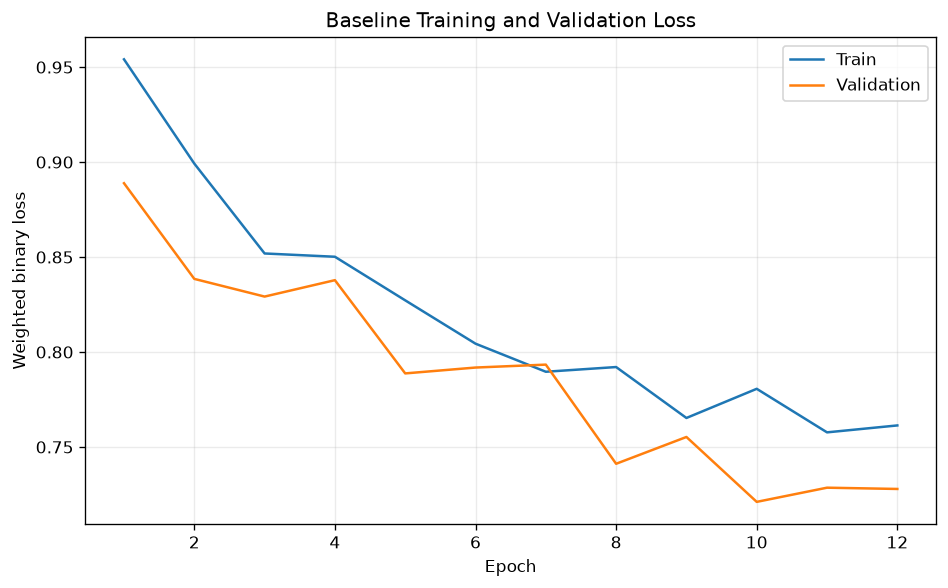

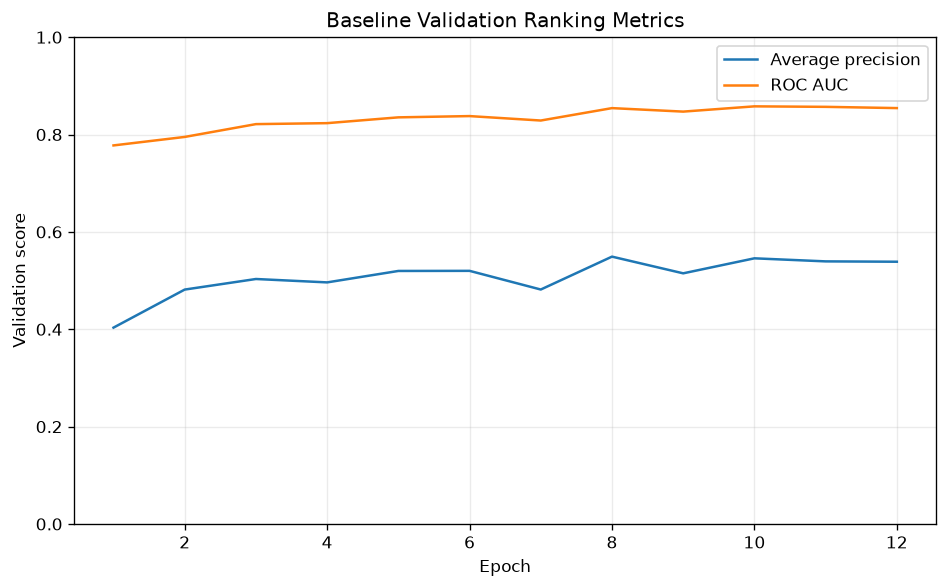

[WindowsPath('output/figures/baseline-loss-by-epoch.png'),
 WindowsPath('output/figures/baseline-validation-metrics-by-epoch.png')]

In [43]:
def plot_training_history(
    history_frame: pd.DataFrame,
    figure_directory: Path,
) -> list[Path]:
    """
    Plot and save baseline loss and validation ranking metrics by epoch.

    Input:
    ------
    history_frame : pd.DataFrame
        Epoch-level training and validation metrics.
    figure_directory : Path
        Directory in which generated figures are saved.

    Outputs:
    --------
    figure_paths : list[Path]
        Paths of the saved loss and ranking-metric figures.

    Author:
    -------
    Rodrigo Kang
    """
    loss_figure, loss_axis = plt.subplots(figsize=(8, 5))
    loss_axis.plot(history_frame["epoch"], history_frame["train_loss"], label="Train")
    loss_axis.plot(
        history_frame["epoch"],
        history_frame["validation_loss"],
        label="Validation",
    )
    loss_axis.set_xlabel("Epoch")
    loss_axis.set_ylabel("Weighted binary loss")
    loss_axis.set_title("Baseline Training and Validation Loss")
    loss_axis.legend()
    loss_axis.grid(alpha=0.25)
    loss_figure.tight_layout()
    loss_path = figure_directory / "baseline-loss-by-epoch.png"
    loss_figure.savefig(loss_path, dpi=160, bbox_inches="tight")
    plt.show()

    metric_figure, metric_axis = plt.subplots(figsize=(8, 5))
    metric_axis.plot(
        history_frame["epoch"],
        history_frame["validation_average_precision"],
        label="Average precision",
    )
    metric_axis.plot(
        history_frame["epoch"],
        history_frame["validation_roc_auc"],
        label="ROC AUC",
    )
    metric_axis.set_xlabel("Epoch")
    metric_axis.set_ylabel("Validation score")
    metric_axis.set_ylim(0.0, 1.0)
    metric_axis.set_title("Baseline Validation Ranking Metrics")
    metric_axis.legend()
    metric_axis.grid(alpha=0.25)
    metric_figure.tight_layout()
    metric_path = figure_directory / "baseline-validation-metrics-by-epoch.png"
    metric_figure.savefig(metric_path, dpi=160, bbox_inches="tight")
    plt.show()

    return [loss_path, metric_path]

training_figure_paths = plot_training_history(
    history_frame=training_history,
    figure_directory=output_directories["figures"],
)
training_figure_paths

### Reload Selected Validation Checkpoint

The selected checkpoint is loaded into a fresh model instance and evaluated again on validation. This confirms that the saved state reproduces the selected result. No test predictions are generated.

In [44]:
selected_checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
selected_baseline_model = BaselineConvNet(
    dropout_probability=selected_checkpoint["model_configuration"]["dropout_probability"]
).to(device)
selected_baseline_model.load_state_dict(selected_checkpoint["model_state_dict"])

selected_validation_metrics = evaluate_binary_model(
    model=selected_baseline_model,
    data_loader=validation_loader,
    criterion=loss_function,
    compute_device=device,
    reporting_threshold=validation_reporting_threshold,
)

selected_validation_summary = {
    key: float(value)
    for key, value in selected_validation_metrics.items()
    if np.isscalar(value)
}
selected_validation_summary["selected_epoch"] = int(selected_checkpoint["epoch"])

print(selected_validation_summary)
assert np.isclose(
    selected_validation_summary["average_precision"],
    selected_checkpoint["validation_metrics"]["average_precision"],
)

{'loss': 0.7411689452757715, 'roc_auc': 0.8543086177897603, 'average_precision': 0.5492251509359081, 'precision_at_0_5': 0.4444444444444444, 'sensitivity_at_0_5': 0.7625418060200669, 'specificity_at_0_5': 0.7638773819386909, 'f1_at_0_5': 0.5615763546798029, 'selected_epoch': 8}


## Validation Threshold Selection and Final Test Evaluation

This section selects one operating threshold from validation predictions and then evaluates the frozen baseline once on the untouched test partition.

Threshold selection maximises the validation F2 score, giving more weight to sensitivity than precision. This is a project-specific analytical choice, not a clinically validated referral rule. Test results are reported at both image and lesion level and should be interpreted within the limits of this dataset.

### Evaluation Imports

Only the additional scikit-learn metrics required for threshold analysis, calibration, and diagnostic plots are introduced here.

In [45]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    brier_score_loss,
    precision_recall_curve,
    roc_curve,
)

### Evaluation Configuration

The operating threshold is selected on validation by maximising the F2 score. This places greater weight on sensitivity while retaining a penalty for false positives.

The choice provides a transparent comparison point for the project. It does not define an appropriate threshold for clinical use, where prevalence, workflow capacity, and the consequences of errors would need separate consideration.

In [46]:
threshold_beta = 2.0
calibration_bin_count = 10

validation_predictions_path = output_directories["tables"] / "validation-predictions.csv"
test_predictions_path = output_directories["tables"] / "test-predictions.csv"
lesion_test_predictions_path = output_directories["tables"] / "test-lesion-predictions.csv"
threshold_table_path = output_directories["tables"] / "validation-threshold-analysis.csv"
final_metrics_path = output_directories["metadata"] / "baseline-final-test-metrics.json"
selected_threshold_path = output_directories["metadata"] / "selected-validation-threshold.json"

### Prediction Collection

Predictions are collected with deterministic evaluation transforms. Image identifiers, lesion identifiers, and source diagnoses are retained so that aggregate results can be traced back to individual records.

In [47]:
def collect_model_predictions(
    model: nn.Module,
    data_loader: DataLoader,
    compute_device: torch.device,
) -> pd.DataFrame:
    """
    Collect probabilities, targets and traceability fields for one partition.

    Input:
    ------
    model : nn.Module
        Trained binary image model evaluated without parameter updates.
    data_loader : DataLoader
        Deterministic non-training data loader.
    compute_device : torch.device
        Device used for model inference.

    Outputs:
    --------
    prediction_frame : pd.DataFrame
        Image-level targets, probabilities and identifying metadata.

    Author:
    -------
    Rodrigo Kang
    """
    model.eval()
    records = []

    with torch.no_grad():
        for image_batch, target_batch, metadata_batch in data_loader:
            logits = model(image_batch.to(compute_device, non_blocking=True))
            probabilities = torch.sigmoid(logits).cpu().numpy()

            for index in range(len(target_batch)):
                records.append(
                    {
                        "image_id": metadata_batch["image_id"][index],
                        "lesion_id": metadata_batch["lesion_id"][index],
                        "source_diagnosis": metadata_batch["source_diagnosis"][index],
                        "binary_target": int(target_batch[index].item()),
                        "probability": float(probabilities[index]),
                    }
                )

    prediction_frame = pd.DataFrame.from_records(records)
    assert len(prediction_frame) == len(data_loader.dataset)
    assert prediction_frame["probability"].between(0.0, 1.0).all()
    return prediction_frame

def calculate_threshold_metrics(
    targets: np.ndarray,
    probabilities: np.ndarray,
    threshold: float,
    beta: float,
) -> dict[str, float]:
    """
    Calculate binary classification metrics at one probability threshold.

    Input:
    ------
    targets : np.ndarray
        Observed binary targets.
    probabilities : np.ndarray
        Predicted positive-class probabilities.
    threshold : float
        Probability cut-off used to create binary predictions.
    beta : float
        Relative recall emphasis used in the F-beta score.

    Outputs:
    --------
    metrics : dict[str, float]
        Confusion counts and threshold-dependent performance measures.

    Author:
    -------
    Rodrigo Kang
    """
    predictions = (probabilities >= threshold).astype(int)
    true_negative, false_positive, false_negative, true_positive = confusion_matrix(
        targets, predictions, labels=[0, 1]
    ).ravel()

    precision = true_positive / max(true_positive + false_positive, 1)
    sensitivity = true_positive / max(true_positive + false_negative, 1)
    specificity = true_negative / max(true_negative + false_positive, 1)
    negative_predictive_value = true_negative / max(true_negative + false_negative, 1)
    beta_squared = beta ** 2
    f_beta = (
        (1.0 + beta_squared) * precision * sensitivity
        / max(beta_squared * precision + sensitivity, np.finfo(float).eps)
    )

    return {
        "threshold": float(threshold),
        "true_negative": int(true_negative),
        "false_positive": int(false_positive),
        "false_negative": int(false_negative),
        "true_positive": int(true_positive),
        "precision": float(precision),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "negative_predictive_value": float(negative_predictive_value),
        "f_beta": float(f_beta),
    }

def build_threshold_analysis(
    targets: np.ndarray,
    probabilities: np.ndarray,
    beta: float,
) -> pd.DataFrame:
    """
    Evaluate all distinct validation thresholds and their operating metrics.

    Input:
    ------
    targets : np.ndarray
        Observed validation targets.
    probabilities : np.ndarray
        Validation positive-class probabilities.
    beta : float
        Relative recall emphasis used in the F-beta score.

    Outputs:
    --------
    threshold_frame : pd.DataFrame
        Candidate thresholds and associated validation metrics.

    Author:
    -------
    Rodrigo Kang
    """
    _, _, candidate_thresholds = precision_recall_curve(targets, probabilities)
    candidate_thresholds = np.unique(
        np.concatenate(([0.0], candidate_thresholds, [1.0]))
    )
    threshold_frame = pd.DataFrame(
        [
            calculate_threshold_metrics(targets, probabilities, threshold, beta)
            for threshold in candidate_thresholds
        ]
    )
    return threshold_frame.sort_values("threshold").reset_index(drop=True)

def select_validation_threshold(
    threshold_frame: pd.DataFrame,
) -> pd.Series:
    """
    Select the validation threshold with maximum F-beta performance.

    Input:
    ------
    threshold_frame : pd.DataFrame
        Validation metrics for candidate probability thresholds.

    Outputs:
    --------
    selected_row : pd.Series
        Selected operating point, breaking ties by sensitivity then specificity.

    Author:
    -------
    Rodrigo Kang
    """
    ranked = threshold_frame.sort_values(
        ["f_beta", "sensitivity", "specificity", "threshold"],
        ascending=[False, False, False, False],
    )
    return ranked.iloc[0].copy()

### Validation-Only Threshold Selection

The selected checkpoint is evaluated on validation first. The full threshold table is saved, and the chosen threshold is fixed before any test predictions are generated.

In [48]:
validation_prediction_frame = collect_model_predictions(
    model=selected_baseline_model,
    data_loader=validation_loader,
    compute_device=device,
)
validation_prediction_frame.to_csv(validation_predictions_path, index=False)

validation_threshold_frame = build_threshold_analysis(
    targets=validation_prediction_frame["binary_target"].to_numpy(),
    probabilities=validation_prediction_frame["probability"].to_numpy(),
    beta=threshold_beta,
)
validation_threshold_frame.to_csv(threshold_table_path, index=False)
selected_threshold_row = select_validation_threshold(validation_threshold_frame)
selected_probability_threshold = float(selected_threshold_row["threshold"])

selected_threshold_summary = {
    "selection_partition": "validation",
    "selection_rule": "maximum-f2",
    "beta": threshold_beta,
    **{key: float(value) for key, value in selected_threshold_row.items()},
}
with selected_threshold_path.open("w", encoding="utf-8") as file:
    json.dump(selected_threshold_summary, file, indent=2)

print(selected_threshold_summary)
print(f"Selected validation threshold: {selected_probability_threshold:.4f}")

{'selection_partition': 'validation', 'selection_rule': 'maximum-f2', 'beta': 2.0, 'threshold': 0.2987675070762634, 'true_negative': 639.0, 'false_positive': 568.0, 'false_negative': 4.0, 'true_positive': 295.0, 'precision': 0.34183082271147164, 'sensitivity': 0.9866220735785953, 'specificity': 0.5294117647058824, 'negative_predictive_value': 0.9937791601866252, 'f_beta': 0.7163671685284118}
Selected validation threshold: 0.2988


### Validation Curves and Calibration

ROC and precision–recall curves summarise ranking performance across thresholds. The calibration plot and Brier score assess how closely predicted probabilities align with observed outcomes within validation.

These diagnostics support model assessment but do not establish calibration beyond the supplied data.

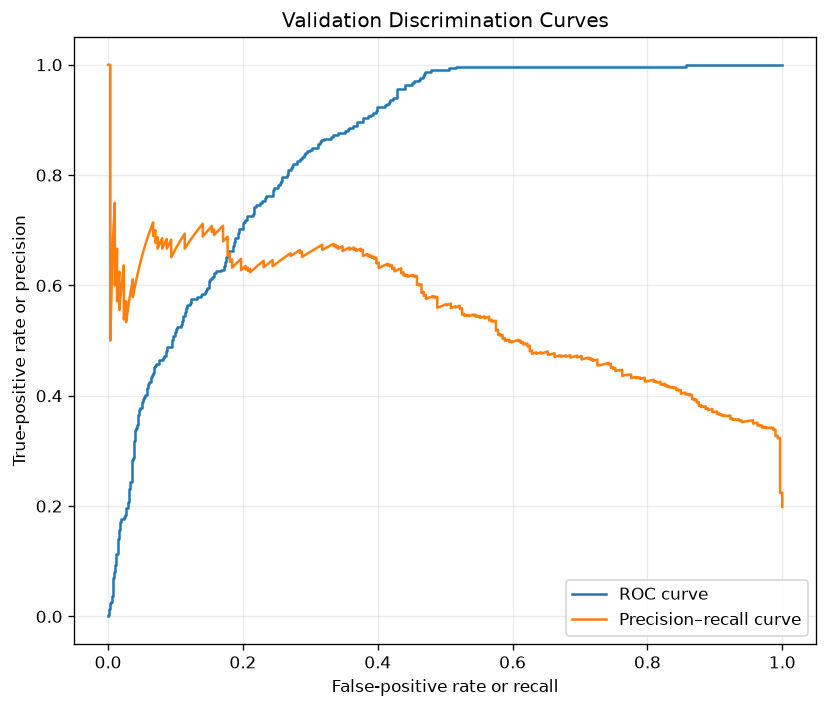

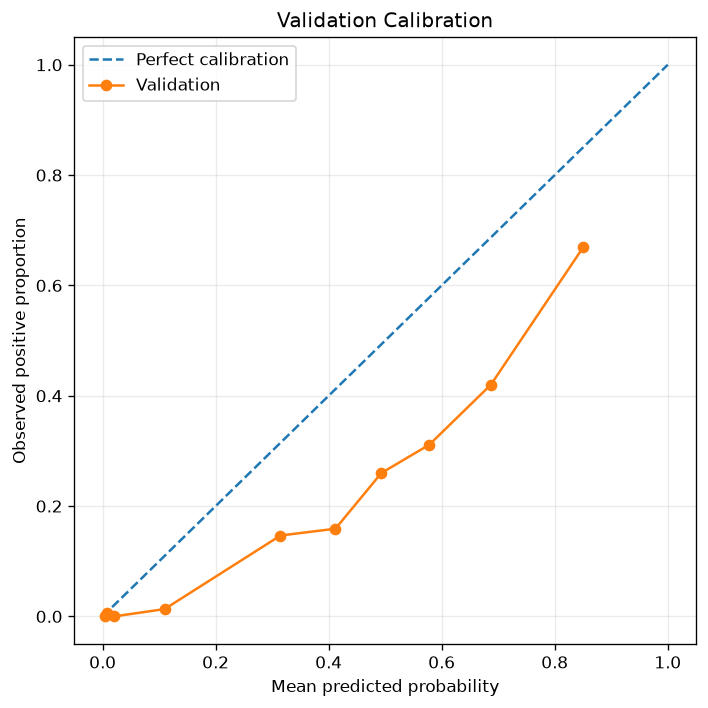

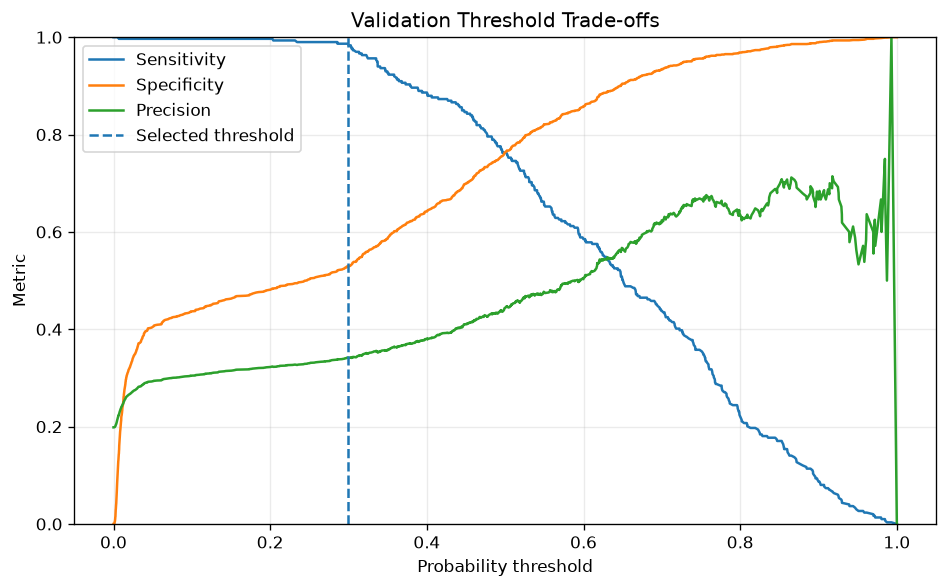

[WindowsPath('output/figures/validation-discrimination-curves.png'),
 WindowsPath('output/figures/validation-calibration-curve.png'),
 WindowsPath('output/figures/validation-threshold-tradeoffs.png')]

In [49]:
def plot_discrimination_and_calibration(
    prediction_frame: pd.DataFrame,
    selected_threshold: float,
    calibration_bins: int,
    figure_directory: Path,
    partition_name: str,
) -> list[Path]:
    """
    Plot discrimination curves, threshold trade-offs and calibration.

    Input:
    ------
    prediction_frame : pd.DataFrame
        Observed targets and model probabilities for one partition.
    selected_threshold : float
        Validation-selected probability operating point.
    calibration_bins : int
        Number of quantile-based calibration bins.
    figure_directory : Path
        Directory in which generated figures are saved.
    partition_name : str
        Partition label used in titles and file names.

    Outputs:
    --------
    figure_paths : list[Path]
        Paths of saved discrimination, trade-off and calibration figures.

    Author:
    -------
    Rodrigo Kang
    """
    targets = prediction_frame["binary_target"].to_numpy()
    probabilities = prediction_frame["probability"].to_numpy()
    file_prefix = partition_name.lower().replace("_", "-")

    false_positive_rate, true_positive_rate, _ = roc_curve(targets, probabilities)
    precision, recall, _ = precision_recall_curve(targets, probabilities)

    discrimination_figure, discrimination_axis = plt.subplots(figsize=(7, 6))
    discrimination_axis.plot(false_positive_rate, true_positive_rate, label="ROC curve")
    discrimination_axis.plot(recall, precision, label="Precision–recall curve")
    discrimination_axis.set_xlabel("False-positive rate or recall")
    discrimination_axis.set_ylabel("True-positive rate or precision")
    discrimination_axis.set_title(f"{partition_name.title()} Discrimination Curves")
    discrimination_axis.legend()
    discrimination_axis.grid(alpha=0.25)
    discrimination_figure.tight_layout()
    discrimination_path = figure_directory / f"{file_prefix}-discrimination-curves.png"
    discrimination_figure.savefig(discrimination_path, dpi=160, bbox_inches="tight")
    plt.show()

    calibration_observed, calibration_predicted = calibration_curve(
        targets, probabilities, n_bins=calibration_bins, strategy="quantile"
    )
    calibration_figure, calibration_axis = plt.subplots(figsize=(6, 6))
    calibration_axis.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    calibration_axis.plot(
        calibration_predicted, calibration_observed, marker="o", label=partition_name.title()
    )
    calibration_axis.set_xlabel("Mean predicted probability")
    calibration_axis.set_ylabel("Observed positive proportion")
    calibration_axis.set_title(f"{partition_name.title()} Calibration")
    calibration_axis.legend()
    calibration_axis.grid(alpha=0.25)
    calibration_figure.tight_layout()
    calibration_path = figure_directory / f"{file_prefix}-calibration-curve.png"
    calibration_figure.savefig(calibration_path, dpi=160, bbox_inches="tight")
    plt.show()

    threshold_metrics = build_threshold_analysis(targets, probabilities, threshold_beta)
    tradeoff_figure, tradeoff_axis = plt.subplots(figsize=(8, 5))
    tradeoff_axis.plot(threshold_metrics["threshold"], threshold_metrics["sensitivity"], label="Sensitivity")
    tradeoff_axis.plot(threshold_metrics["threshold"], threshold_metrics["specificity"], label="Specificity")
    tradeoff_axis.plot(threshold_metrics["threshold"], threshold_metrics["precision"], label="Precision")
    tradeoff_axis.axvline(selected_threshold, linestyle="--", label="Selected threshold")
    tradeoff_axis.set_xlabel("Probability threshold")
    tradeoff_axis.set_ylabel("Metric")
    tradeoff_axis.set_ylim(0.0, 1.0)
    tradeoff_axis.set_title(f"{partition_name.title()} Threshold Trade-offs")
    tradeoff_axis.legend()
    tradeoff_axis.grid(alpha=0.25)
    tradeoff_figure.tight_layout()
    tradeoff_path = figure_directory / f"{file_prefix}-threshold-tradeoffs.png"
    tradeoff_figure.savefig(tradeoff_path, dpi=160, bbox_inches="tight")
    plt.show()

    return [discrimination_path, calibration_path, tradeoff_path]

validation_evaluation_figure_paths = plot_discrimination_and_calibration(
    prediction_frame=validation_prediction_frame,
    selected_threshold=selected_probability_threshold,
    calibration_bins=calibration_bin_count,
    figure_directory=output_directories["figures"],
    partition_name="validation",
)
validation_evaluation_figure_paths

### Single Final Test Evaluation

After the threshold has been fixed, the same model, preprocessing pipeline, and decision rule are applied once to the test partition. No further tuning is performed.

The resulting metrics describe this held-out split only and are not evidence of external or clinical validity.

In [50]:
test_prediction_frame = collect_model_predictions(
    model=selected_baseline_model,
    data_loader=test_loader,
    compute_device=device,
)
test_prediction_frame["predicted_target"] = (
    test_prediction_frame["probability"] >= selected_probability_threshold
).astype(int)
test_prediction_frame.to_csv(test_predictions_path, index=False)

test_targets = test_prediction_frame["binary_target"].to_numpy()
test_probabilities = test_prediction_frame["probability"].to_numpy()
image_level_test_metrics = calculate_threshold_metrics(
    targets=test_targets,
    probabilities=test_probabilities,
    threshold=selected_probability_threshold,
    beta=threshold_beta,
)
image_level_test_metrics.update(
    {
        "roc_auc": float(roc_auc_score(test_targets, test_probabilities)),
        "average_precision": float(average_precision_score(test_targets, test_probabilities)),
        "brier_score": float(brier_score_loss(test_targets, test_probabilities)),
        "image_count": int(len(test_prediction_frame)),
    }
)
print(image_level_test_metrics)

{'threshold': 0.2987675070762634, 'true_negative': 647, 'false_positive': 565, 'false_negative': 14, 'true_positive': 269, 'precision': 0.3225419664268585, 'sensitivity': 0.950530035335689, 'specificity': 0.5338283828382838, 'negative_predictive_value': 0.9788199697428139, 'f_beta': 0.6841302136317394, 'roc_auc': 0.848505521930285, 'average_precision': 0.5583247475602797, 'brier_score': 0.14963511143316913, 'image_count': 1495}


### Lesion-Level Sensitivity Analysis

Some lesions have several photographs. A secondary lesion-level analysis therefore aggregates image probabilities using the maximum value for each lesion.

This reflects a setting in which any available image could trigger prioritisation. It is a sensitivity analysis rather than a validated aggregation rule.

In [51]:
def aggregate_predictions_by_lesion(
    prediction_frame: pd.DataFrame,
    threshold: float,
) -> pd.DataFrame:
    """
    Aggregate repeated image predictions into one record per lesion.

    Input:
    ------
    prediction_frame : pd.DataFrame
        Image-level targets, probabilities and lesion identifiers.
    threshold : float
        Fixed validation-selected probability threshold.

    Outputs:
    --------
    lesion_frame : pd.DataFrame
        Lesion-level targets, maximum probabilities and predictions.

    Author:
    -------
    Rodrigo Kang
    """
    target_consistency = prediction_frame.groupby("lesion_id")["binary_target"].nunique()
    if not target_consistency.eq(1).all():
        raise ValueError("At least one lesion has inconsistent binary targets.")

    lesion_frame = (
        prediction_frame.groupby("lesion_id", as_index=False)
        .agg(
            binary_target=("binary_target", "first"),
            probability=("probability", "max"),
            image_count=("image_id", "count"),
        )
    )
    lesion_frame["predicted_target"] = (
        lesion_frame["probability"] >= threshold
    ).astype(int)
    return lesion_frame

test_lesion_prediction_frame = aggregate_predictions_by_lesion(
    prediction_frame=test_prediction_frame,
    threshold=selected_probability_threshold,
)
test_lesion_prediction_frame.to_csv(lesion_test_predictions_path, index=False)

lesion_targets = test_lesion_prediction_frame["binary_target"].to_numpy()
lesion_probabilities = test_lesion_prediction_frame["probability"].to_numpy()
lesion_level_test_metrics = calculate_threshold_metrics(
    targets=lesion_targets,
    probabilities=lesion_probabilities,
    threshold=selected_probability_threshold,
    beta=threshold_beta,
)
lesion_level_test_metrics.update(
    {
        "roc_auc": float(roc_auc_score(lesion_targets, lesion_probabilities)),
        "average_precision": float(average_precision_score(lesion_targets, lesion_probabilities)),
        "brier_score": float(brier_score_loss(lesion_targets, lesion_probabilities)),
        "lesion_count": int(len(test_lesion_prediction_frame)),
        "aggregation": "maximum-image-probability",
    }
)
print(lesion_level_test_metrics)

{'threshold': 0.2987675070762634, 'true_negative': 604, 'false_positive': 341, 'false_negative': 6, 'true_positive': 170, 'precision': 0.33268101761252444, 'sensitivity': 0.9659090909090909, 'specificity': 0.6391534391534391, 'negative_predictive_value': 0.9901639344262295, 'f_beta': 0.6995884773662552, 'roc_auc': 0.8987073112073112, 'average_precision': 0.5999319045421065, 'brier_score': 0.12333402397737188, 'lesion_count': 1121, 'aggregation': 'maximum-image-probability'}


### Test Confusion Matrix and Curves

The confusion matrix makes false negatives and false positives visible at the frozen threshold. ROC, precision–recall, and calibration plots provide complementary final diagnostics.

The test set is used for reporting only; it does not influence the threshold or model selection.

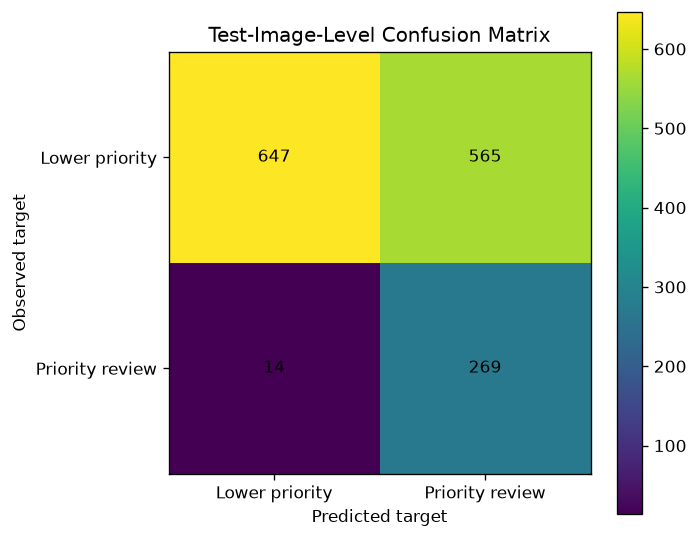

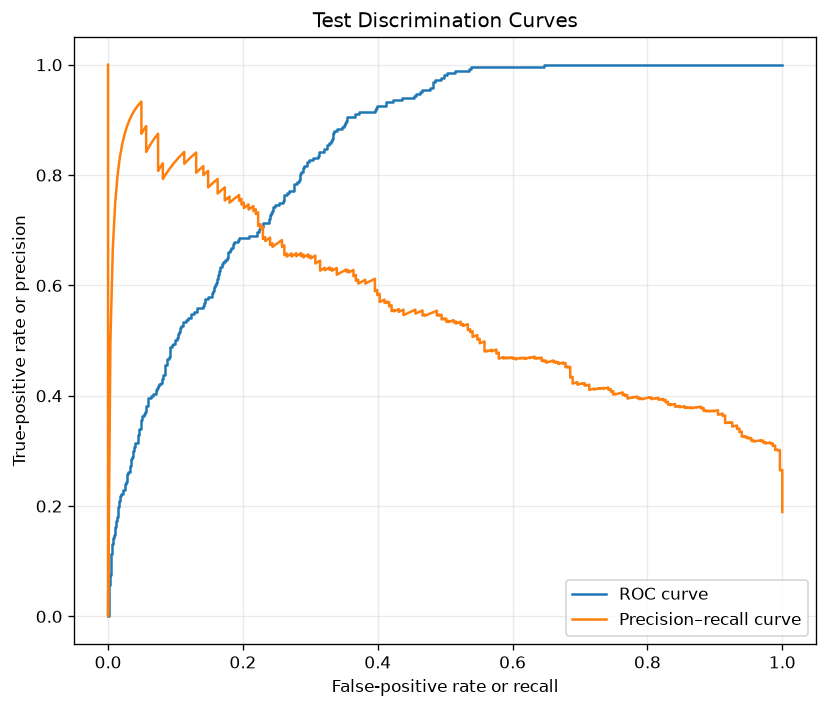

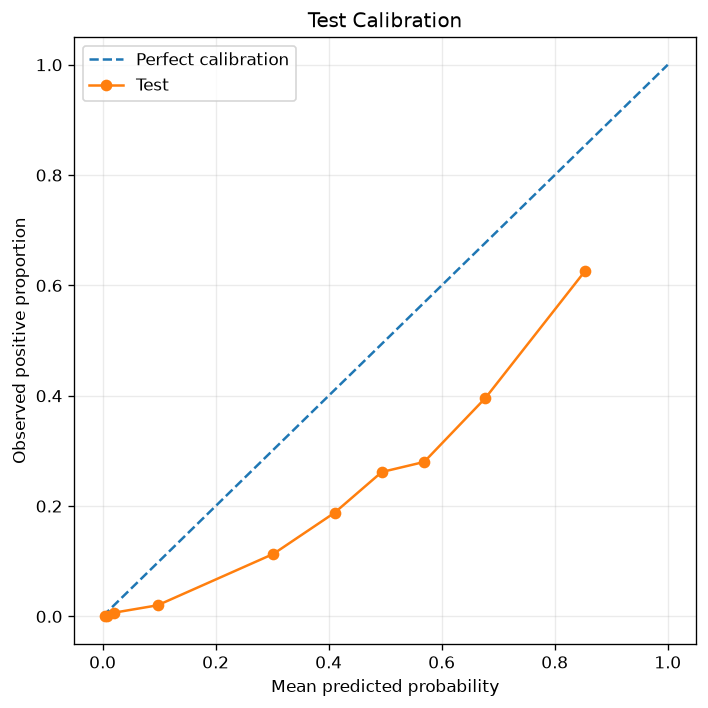

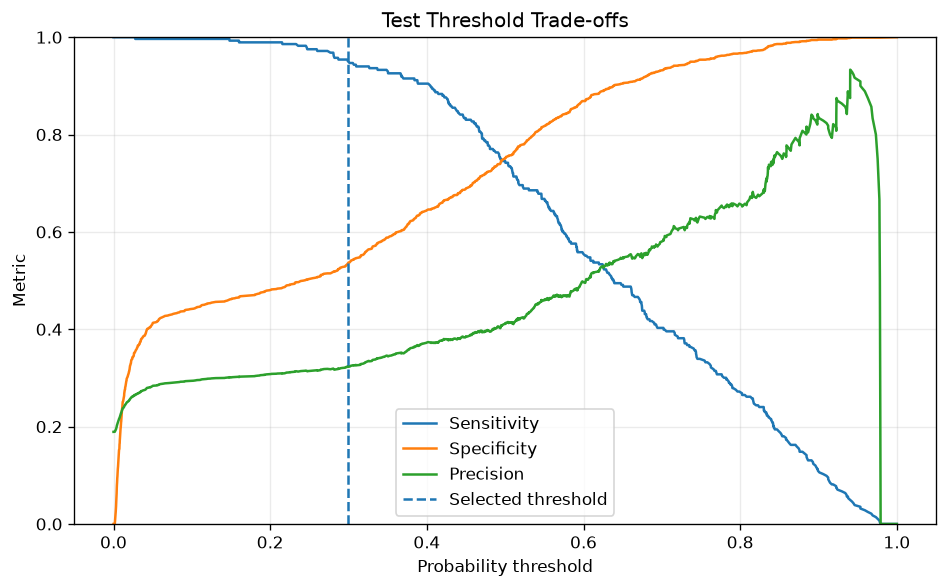

In [52]:
def plot_confusion_matrix(
    metrics: Mapping[str, float],
    figure_directory: Path,
    partition_name: str,
) -> Path:
    """
    Plot and save a two-class confusion matrix from metric counts.

    Input:
    ------
    metrics : Mapping[str, float]
        Mapping containing true-negative, false-positive, false-negative and true-positive counts.
    figure_directory : Path
        Directory in which the figure is saved.
    partition_name : str
        Partition label used in the figure title and file name.

    Outputs:
    --------
    figure_path : Path
        Path of the saved confusion-matrix figure.

    Author:
    -------
    Rodrigo Kang
    """
    matrix = np.array(
        [
            [metrics["true_negative"], metrics["false_positive"]],
            [metrics["false_negative"], metrics["true_positive"]],
        ]
    )
    figure, axis = plt.subplots(figsize=(6, 5))
    image = axis.imshow(matrix)
    figure.colorbar(image, ax=axis)
    axis.set_xticks([0, 1], labels=["Lower priority", "Priority review"])
    axis.set_yticks([0, 1], labels=["Lower priority", "Priority review"])
    axis.set_xlabel("Predicted target")
    axis.set_ylabel("Observed target")
    axis.set_title(f"{partition_name.title()} Confusion Matrix")
    for row in range(2):
        for column in range(2):
            axis.text(column, row, f"{matrix[row, column]:,}", ha="center", va="center")
    figure.tight_layout()
    figure_path = figure_directory / f"{partition_name.lower().replace('_', '-')}-confusion-matrix.png"
    figure.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    return figure_path

test_confusion_matrix_path = plot_confusion_matrix(
    metrics=image_level_test_metrics,
    figure_directory=output_directories["figures"],
    partition_name="test-image-level",
)
test_evaluation_figure_paths = plot_discrimination_and_calibration(
    prediction_frame=test_prediction_frame,
    selected_threshold=selected_probability_threshold,
    calibration_bins=calibration_bin_count,
    figure_directory=output_directories["figures"],
    partition_name="test",
)

### Error and Diagnosis Breakdown

Results are also summarised by source diagnosis to show variation that may be hidden by the binary aggregate. Estimates for small categories should be interpreted cautiously because a few observations can materially change the reported rates.

In [53]:
def summarise_predictions_by_diagnosis(
    prediction_frame: pd.DataFrame,
) -> pd.DataFrame:
    """
    Summarise observed outcomes and predictions for each source diagnosis.

    Input:
    ------
    prediction_frame : pd.DataFrame
        Test predictions containing source diagnoses and fixed-threshold outputs.

    Outputs:
    --------
    diagnosis_summary : pd.DataFrame
        Counts, mean probabilities and predicted-priority rates by diagnosis.

    Author:
    -------
    Rodrigo Kang
    """
    diagnosis_summary = (
        prediction_frame.groupby("source_diagnosis", as_index=False)
        .agg(
            image_count=("image_id", "count"),
            observed_priority_rate=("binary_target", "mean"),
            mean_probability=("probability", "mean"),
            predicted_priority_rate=("predicted_target", "mean"),
        )
        .sort_values("image_count", ascending=False)
        .reset_index(drop=True)
    )
    return diagnosis_summary

test_diagnosis_summary = summarise_predictions_by_diagnosis(test_prediction_frame)
test_diagnosis_summary_path = (
    output_directories["tables"] / "test-predictions-by-source-diagnosis.csv"
)
test_diagnosis_summary.to_csv(test_diagnosis_summary_path, index=False)

false_negative_frame = test_prediction_frame.loc[
    (test_prediction_frame["binary_target"] == 1)
    & (test_prediction_frame["predicted_target"] == 0)
].sort_values("probability")
false_positive_frame = test_prediction_frame.loc[
    (test_prediction_frame["binary_target"] == 0)
    & (test_prediction_frame["predicted_target"] == 1)
].sort_values("probability", ascending=False)

false_negative_path = output_directories["tables"] / "test-false-negatives.csv"
false_positive_path = output_directories["tables"] / "test-false-positives.csv"
false_negative_frame.to_csv(false_negative_path, index=False)
false_positive_frame.to_csv(false_positive_path, index=False)

print(test_diagnosis_summary.to_string(index=False))
print(f"False negatives: {len(false_negative_frame):,}")
print(f"False positives: {len(false_positive_frame):,}")

source_diagnosis  image_count  observed_priority_rate  mean_probability  predicted_priority_rate
              nv         1010                     0.0          0.225164                 0.389109
             bkl          163                     0.0          0.529783                 0.883436
             mel          156                     1.0          0.594852                 0.935897
             bcc           81                     1.0          0.650427                 0.950617
           akiec           46                     1.0          0.794857                 1.000000
              df           22                     0.0          0.544047                 0.818182
            vasc           17                     0.0          0.352578                 0.588235
False negatives: 14
False positives: 565


### Persist Final Evaluation Summary

The final evaluation record stores the frozen validation threshold, checkpoint epoch, and image-level and lesion-level test metrics. Keeping these elements together supports reproducibility while preserving the distinction between model development and final evaluation.

In [54]:
final_test_summary = {
    "model": "BaselineConvNet",
    "checkpoint_epoch": int(selected_checkpoint["epoch"]),
    "threshold_selection": selected_threshold_summary,
    "image_level_test_metrics": image_level_test_metrics,
    "lesion_level_test_metrics": lesion_level_test_metrics,
    "limitations": [
        "The binary target is project-derived rather than an original clinical referral label.",
        "The threshold is selected internally on validation data and is not clinically validated.",
        "HAM10000 acquisition, ground-truth and class composition may not represent deployment settings.",
        "External and prospective validation would be required before any clinical use.",
    ],
}
with final_metrics_path.open("w", encoding="utf-8") as file:
    json.dump(final_test_summary, file, indent=2)

print(json.dumps(final_test_summary, indent=2))
print(f"Saved final metrics: {final_metrics_path}")

{
  "model": "BaselineConvNet",
  "checkpoint_epoch": 8,
  "threshold_selection": {
    "selection_partition": "validation",
    "selection_rule": "maximum-f2",
    "beta": 2.0,
    "threshold": 0.2987675070762634,
    "true_negative": 639.0,
    "false_positive": 568.0,
    "false_negative": 4.0,
    "true_positive": 295.0,
    "precision": 0.34183082271147164,
    "sensitivity": 0.9866220735785953,
    "specificity": 0.5294117647058824,
    "negative_predictive_value": 0.9937791601866252,
    "f_beta": 0.7163671685284118
  },
  "image_level_test_metrics": {
    "threshold": 0.2987675070762634,
    "true_negative": 647,
    "false_positive": 565,
    "false_negative": 14,
    "true_positive": 269,
    "precision": 0.3225419664268585,
    "sensitivity": 0.950530035335689,
    "specificity": 0.5338283828382838,
    "negative_predictive_value": 0.9788199697428139,
    "f_beta": 0.6841302136317394,
    "roc_auc": 0.848505521930285,
    "average_precision": 0.5583247475602797,
    "brier_s

## Interpretability and Qualitative Error Review

This section reviews selected test predictions after the model, checkpoint, and operating threshold have been fixed. It adds a reproducible qualitative error review and Grad-CAM visualisations implemented in PyTorch.

These outputs describe where the model is locally sensitive for selected images. They do not explain clinical causation, validate the binary target, or establish that highlighted regions are medically meaningful. No model parameters, partitions, thresholds, or reported metrics are changed.

### Interpretability Configuration

A fixed number of examples is selected from true positives, true negatives, false negatives, and false positives. Selection is based on model probability with image identifiers used for stable tie-breaking, avoiding manual case choice.

Grad-CAM uses the final convolutional layer because it retains spatial information while representing the deepest features in the compact baseline.

In [55]:
examples_per_error_group = 3
grad_cam_target_layer_name = "features.12"
grad_cam_overlay_alpha = 0.40

qualitative_case_table_path = (
    output_directories["tables"] / "qualitative-test-case-selection.csv"
)
grad_cam_metadata_path = (
    output_directories["metadata"] / "grad-cam-review-summary.json"
)
qualitative_predictions_figure_path = (
    output_directories["figures"] / "qualitative-test-predictions.png"
)
grad_cam_figure_path = (
    output_directories["figures"] / "grad-cam-selected-test-cases.png"
)

assert examples_per_error_group > 0
assert 0.0 <= grad_cam_overlay_alpha <= 1.0

### Reproducible Case Selection

Cases are selected deterministically from the frozen test predictions. True positives and false positives are ordered from highest probability, while true negatives and false negatives are ordered from lowest probability. This highlights confident correct decisions and confident errors.

The sample is intentionally small and should not be treated as a complete error analysis.

In [56]:
def select_qualitative_test_cases(
    prediction_frame: pd.DataFrame,
    examples_per_group: int,
) -> pd.DataFrame:
    """
    Select deterministic high-confidence examples from four prediction outcomes.

    Input:
    ------
    prediction_frame : pd.DataFrame
        Frozen test predictions containing targets, decisions and probabilities.
    examples_per_group : int
        Maximum number of examples retained for each prediction outcome.

    Outputs:
    --------
    selected_cases : pd.DataFrame
        Ordered examples labelled as true positive, true negative, false negative or false positive.

    Author:
    -------
    Rodrigo Kang
    """
    required_columns = {
        "image_id",
        "lesion_id",
        "source_diagnosis",
        "binary_target",
        "predicted_target",
        "probability",
    }
    missing_columns = required_columns - set(prediction_frame.columns)
    if missing_columns:
        raise ValueError(f"Prediction columns are missing: {sorted(missing_columns)}")

    outcome_definitions = [
        ("true-positive", 1, 1, False),
        ("true-negative", 0, 0, True),
        ("false-negative", 1, 0, True),
        ("false-positive", 0, 1, False),
    ]
    selected_frames = []

    for outcome_name, observed_target, predicted_target, ascending_probability in outcome_definitions:
        outcome_frame = prediction_frame.loc[
            (prediction_frame["binary_target"] == observed_target)
            & (prediction_frame["predicted_target"] == predicted_target)
        ].copy()
        outcome_frame = outcome_frame.sort_values(
            ["probability", "image_id"],
            ascending=[ascending_probability, True],
        ).head(examples_per_group)
        outcome_frame["prediction_outcome"] = outcome_name
        outcome_frame["selection_rank"] = np.arange(1, len(outcome_frame) + 1)
        selected_frames.append(outcome_frame)

    selected_cases = pd.concat(selected_frames, ignore_index=True)
    outcome_order = {
        "true-positive": 0,
        "true-negative": 1,
        "false-negative": 2,
        "false-positive": 3,
    }
    selected_cases["outcome_order"] = selected_cases["prediction_outcome"].map(outcome_order)
    selected_cases = selected_cases.sort_values(
        ["outcome_order", "selection_rank", "image_id"]
    ).drop(columns="outcome_order").reset_index(drop=True)
    return selected_cases

qualitative_case_frame = select_qualitative_test_cases(
    prediction_frame=test_prediction_frame,
    examples_per_group=examples_per_error_group,
)
qualitative_case_frame.to_csv(qualitative_case_table_path, index=False)
print(qualitative_case_frame[
    [
        "prediction_outcome",
        "selection_rank",
        "image_id",
        "lesion_id",
        "source_diagnosis",
        "binary_target",
        "predicted_target",
        "probability",
    ]
].to_string(index=False))

prediction_outcome  selection_rank     image_id  lesion_id source_diagnosis  binary_target  predicted_target  probability
     true-positive               1 ISIC_0025709 IL_2047893              mel              1                 1     0.978360
     true-positive               2 ISIC_0032960 IL_5333822              mel              1                 1     0.977745
     true-positive               3 ISIC_0024913 IL_0807184            akiec              1                 1     0.975476
     true-negative               1 ISIC_0032101 IL_4519493               nv              0                 0     0.001608
     true-negative               2 ISIC_0025212 IL_9880457               nv              0                 0     0.001624
     true-negative               3 ISIC_0029853 IL_8959579               nv              0                 0     0.001664
    false-negative               1 ISIC_0027793 IL_2971333              mel              1                 0     0.027656
    false-negative      

### Raw Image Access and Display Helpers

Selected images are read directly from the compressed archive. Original RGB images are kept separate from the transformed tensors used by the model, avoiding confusion between display images and normalised inputs.

In [57]:
def read_rgb_image_from_archive(
    archive_path: Path,
    member_lookup: Mapping[str, str],
    image_id: str,
) -> Image.Image:
    """
    Read one RGB image from the compressed archive without extracting it.

    Input:
    ------
    archive_path : Path
        Path to the compressed image archive.
    member_lookup : Mapping[str, str]
        Mapping from image identifiers to exact archive member names.
    image_id : str
        Identifier of the requested image.

    Outputs:
    --------
    image : Image.Image
        Independent RGB copy of the requested image.

    Author:
    -------
    Rodrigo Kang
    """
    if image_id not in member_lookup:
        raise KeyError(f"Image identifier is absent from the archive lookup: {image_id}")

    with zipfile.ZipFile(archive_path) as archive:
        with archive.open(member_lookup[image_id]) as image_file:
            image = Image.open(image_file).convert("RGB").copy()
    return image

def plot_qualitative_predictions(
    selected_cases: pd.DataFrame,
    archive_path: Path,
    member_lookup: Mapping[str, str],
    figure_path: Path,
) -> Path:
    """
    Plot selected raw test images with frozen prediction details.

    Input:
    ------
    selected_cases : pd.DataFrame
        Deterministically selected test examples.
    archive_path : Path
        Path to the compressed image archive.
    member_lookup : Mapping[str, str]
        Mapping from image identifiers to exact archive member names.
    figure_path : Path
        Destination path for the qualitative figure.

    Outputs:
    --------
    figure_path : Path
        Path of the saved qualitative prediction figure.

    Author:
    -------
    Rodrigo Kang
    """
    if selected_cases.empty:
        raise ValueError("No qualitative cases are available for plotting.")

    column_count = examples_per_error_group
    outcome_names = [
        "true-positive",
        "true-negative",
        "false-negative",
        "false-positive",
    ]
    figure, axes = plt.subplots(
        len(outcome_names),
        column_count,
        figsize=(4.2 * column_count, 4.0 * len(outcome_names)),
        squeeze=False,
    )

    for row_index, outcome_name in enumerate(outcome_names):
        outcome_cases = selected_cases.loc[
            selected_cases["prediction_outcome"] == outcome_name
        ].sort_values("selection_rank")
        for column_index in range(column_count):
            axis = axes[row_index, column_index]
            axis.axis("off")
            if column_index >= len(outcome_cases):
                continue
            case = outcome_cases.iloc[column_index]
            image = read_rgb_image_from_archive(
                archive_path=archive_path,
                member_lookup=member_lookup,
                image_id=case["image_id"],
            )
            axis.imshow(image)
            axis.set_title(
                f"{outcome_name.replace('-', ' ').title()}\n"
                f"{case['source_diagnosis']} | p={case['probability']:.3f}\n"
                f"{case['image_id']}",
                fontsize=9,
            )

    figure.suptitle("Selected Frozen Test Predictions", fontsize=14)
    figure.tight_layout()
    figure.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    return figure_path

plot_qualitative_predictions(
    selected_cases=qualitative_case_frame,
    archive_path=image_archive_path,
    member_lookup=image_member_lookup,
    figure_path=qualitative_predictions_figure_path,
)

NameError: name 'image_member_lookup' is not defined

### Grad-CAM Implementation

Grad-CAM combines feature activations with gradients from the positive-class logit. The resulting heatmap shows regions associated with the model output for a particular forward pass.

It is not a segmentation mask and does not confirm that the model has learned a dermatologically valid feature. Plausible-looking heatmaps can also occur for incorrect predictions.

In [ ]:
class GradCamRecorder:
    """
    Capture activations and gradients from one convolutional model layer.

    Input:
    ------
    target_layer : nn.Module
        Convolutional layer whose spatial activations are recorded.

    Outputs:
    --------
    recorder : GradCamRecorder
        Hook manager storing the most recent activations and gradients.

    Author:
    -------
    Rodrigo Kang
    """

    def __init__(self, target_layer: nn.Module) -> None:
        """
        Register forward and gradient hooks on the selected model layer.

        Input:
        ------
        target_layer : nn.Module
            Convolutional layer whose spatial activations are recorded.

        Outputs:
        --------
        None
            Hook handles and empty recording state are initialised.

        Author:
        -------
        Rodrigo Kang
        """
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(self._record_activations)

    def _record_activations(
        self,
        module: nn.Module,
        inputs: tuple[torch.Tensor, ...],
        output: torch.Tensor,
    ) -> None:
        """
        Store layer activations and attach a gradient hook to the output tensor.

        Input:
        ------
        module : nn.Module
            Layer producing the recorded activation tensor.
        inputs : tuple[torch.Tensor, ...]
            Positional tensors supplied to the hooked layer.
        output : torch.Tensor
            Activation tensor produced by the hooked layer.

        Outputs:
        --------
        None
            Activations and a gradient callback are stored in the recorder.

        Author:
        -------
        Rodrigo Kang
        """
        del module, inputs
        self.activations = output.detach()
        output.register_hook(self._record_gradients)

    def _record_gradients(self, gradients: torch.Tensor) -> None:
        """
        Store gradients propagated through the recorded activation tensor.

        Input:
        ------
        gradients : torch.Tensor
            Gradient tensor associated with the hooked activations.

        Outputs:
        --------
        None
            Gradients are stored in the recorder.

        Author:
        -------
        Rodrigo Kang
        """
        self.gradients = gradients.detach()

    def close(self) -> None:
        """
        Remove the registered forward hook from the model layer.

        Input:
        ------
        None
            The method uses the stored hook handle.

        Outputs:
        --------
        None
            The forward hook is removed.

        Author:
        -------
        Rodrigo Kang
        """
        self.forward_handle.remove()

def calculate_grad_cam(
    model: nn.Module,
    image_tensor: torch.Tensor,
    target_layer: nn.Module,
    compute_device: torch.device,
) -> tuple[np.ndarray, float]:
    """
    Calculate a positive-class Grad-CAM map for one transformed image.

    Input:
    ------
    model : nn.Module
        Trained binary classification model in evaluation mode.
    image_tensor : torch.Tensor
        Normalised image tensor with three channels.
    target_layer : nn.Module
        Final convolutional layer used for spatial attribution.
    compute_device : torch.device
        Device used for the forward and backward passes.

    Outputs:
    --------
    result : tuple[np.ndarray, float]
        Normalised two-dimensional activation map and positive-class probability.

    Author:
    -------
    Rodrigo Kang
    """
    recorder = GradCamRecorder(target_layer)
    model.eval()
    model.zero_grad(set_to_none=True)

    try:
        input_batch = image_tensor.unsqueeze(0).to(compute_device)
        logit = model(input_batch).squeeze()
        probability = torch.sigmoid(logit).item()
        logit.backward()

        if recorder.activations is None or recorder.gradients is None:
            raise RuntimeError("Grad-CAM hooks did not capture activations and gradients.")

        weights = recorder.gradients.mean(dim=(2, 3), keepdim=True)
        activation_map = (weights * recorder.activations).sum(dim=1, keepdim=True)
        activation_map = torch.relu(activation_map)
        activation_map = torch.nn.functional.interpolate(
            activation_map,
            size=image_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False,
        ).squeeze()
        activation_map -= activation_map.min()
        maximum_value = activation_map.max()
        if maximum_value > 0:
            activation_map /= maximum_value
        return activation_map.cpu().numpy(), float(probability)
    finally:
        recorder.close()

### Grad-CAM Review of Selected Cases

Each case is shown as the original image, the Grad-CAM map, and a transparent overlay. Correct predictions and confident errors are reviewed together.

Concentration over the lesion does not by itself demonstrate valid reasoning. Sensitivity to borders, rulers, colour charts, hair, or background areas may indicate reliance on acquisition artefacts.

In [ ]:
def plot_grad_cam_review(
    model: nn.Module,
    selected_cases: pd.DataFrame,
    archive_path: Path,
    member_lookup: Mapping[str, str],
    evaluation_transform: transforms.Compose,
    target_layer: nn.Module,
    compute_device: torch.device,
    overlay_alpha: float,
    figure_path: Path,
) -> Path:
    """
    Plot original images, Grad-CAM maps and overlays for selected test cases.

    Input:
    ------
    model : nn.Module
        Frozen baseline model loaded from the selected checkpoint.
    selected_cases : pd.DataFrame
        Deterministically selected test examples.
    archive_path : Path
        Path to the compressed image archive.
    member_lookup : Mapping[str, str]
        Mapping from image identifiers to exact archive member names.
    evaluation_transform : transforms.Compose
        Deterministic evaluation preprocessing applied before inference.
    target_layer : nn.Module
        Convolutional layer used for Grad-CAM attribution.
    compute_device : torch.device
        Device used for model inference and gradient calculation.
    overlay_alpha : float
        Opacity of the activation map over the original image.
    figure_path : Path
        Destination path for the Grad-CAM review figure.

    Outputs:
    --------
    figure_path : Path
        Path of the saved Grad-CAM review figure.

    Author:
    -------
    Rodrigo Kang
    """
    if selected_cases.empty:
        raise ValueError("No qualitative cases are available for Grad-CAM review.")

    figure, axes = plt.subplots(
        len(selected_cases),
        3,
        figsize=(12, 3.5 * len(selected_cases)),
        squeeze=False,
    )

    for row_index, case in selected_cases.reset_index(drop=True).iterrows():
        original_image = read_rgb_image_from_archive(
            archive_path=archive_path,
            member_lookup=member_lookup,
            image_id=case["image_id"],
        )
        model_tensor = evaluation_transform(original_image)
        activation_map, recomputed_probability = calculate_grad_cam(
            model=model,
            image_tensor=model_tensor,
            target_layer=target_layer,
            compute_device=compute_device,
        )
        resized_original = original_image.resize(
            (activation_map.shape[1], activation_map.shape[0])
        )

        axes[row_index, 0].imshow(resized_original)
        axes[row_index, 0].set_title(
            f"{case['prediction_outcome'].replace('-', ' ').title()}\n"
            f"{case['source_diagnosis']} | p={recomputed_probability:.3f}",
            fontsize=9,
        )
        axes[row_index, 1].imshow(activation_map, cmap="viridis", vmin=0.0, vmax=1.0)
        axes[row_index, 1].set_title("Grad-CAM", fontsize=9)
        axes[row_index, 2].imshow(resized_original)
        axes[row_index, 2].imshow(
            activation_map,
            cmap="viridis",
            alpha=overlay_alpha,
            vmin=0.0,
            vmax=1.0,
        )
        axes[row_index, 2].set_title(f"Overlay | {case['image_id']}", fontsize=9)

        for axis in axes[row_index]:
            axis.axis("off")

    figure.suptitle("Grad-CAM Review of Frozen Test Predictions", fontsize=14)
    figure.tight_layout()
    figure.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    return figure_path

selected_grad_cam_layer = selected_baseline_model.features[12]
assert isinstance(selected_grad_cam_layer, nn.Conv2d)

plot_grad_cam_review(
    model=selected_baseline_model,
    selected_cases=qualitative_case_frame,
    archive_path=image_archive_path,
    member_lookup=image_member_lookup,
    evaluation_transform=evaluation_transform,
    target_layer=selected_grad_cam_layer,
    compute_device=device,
    overlay_alpha=grad_cam_overlay_alpha,
    figure_path=grad_cam_figure_path,
)

### Persist Interpretability Summary

The saved record documents the selected cases, target layer, and main interpretability limitations. It contains no revised predictions or decision rules because this review is not used to retune the evaluated baseline.

In [ ]:
grad_cam_review_summary = {
    "model_checkpoint": str(best_checkpoint_path),
    "test_threshold": float(selected_probability_threshold),
    "target_layer": grad_cam_target_layer_name,
    "examples_per_error_group": int(examples_per_error_group),
    "selected_case_count": int(len(qualitative_case_frame)),
    "selection_method": {
        "true_positive": "highest-probability",
        "true_negative": "lowest-probability",
        "false_negative": "lowest-probability",
        "false_positive": "highest-probability",
        "tie_breaker": "image-id",
    },
    "class_attribution": "positive-priority-review-logit",
    "interpretation_limits": [
        "post-hoc sensitivity map rather than causal explanation",
        "not a lesion segmentation mask",
        "not evidence of clinically valid reasoning",
        "not used to revise the model, threshold or test metrics",
    ],
    "artifacts": {
        "selected_cases": str(qualitative_case_table_path),
        "qualitative_predictions_figure": str(qualitative_predictions_figure_path),
        "grad_cam_figure": str(grad_cam_figure_path),
    },
}

with grad_cam_metadata_path.open("w", encoding="utf-8") as metadata_file:
    json.dump(grad_cam_review_summary, metadata_file, indent=2)

print(json.dumps(grad_cam_review_summary, indent=2))

## Robustness, Subgroup Review and Project Closure

This section consolidates the frozen baseline without changing the trained model, validation-selected threshold, or test predictions. It estimates sampling uncertainty with lesion-aware bootstrap intervals, reviews performance across selected metadata groups, and records the main artefacts required to reproduce the experiment.

The analysis remains descriptive. Subgroup differences may reflect sample size, case mix, acquisition conditions, diagnosis mix, or missing metadata, and should not be interpreted as evidence of fairness or causal effects.

### Robustness Configuration

Bootstrap samples are drawn at lesion level so that repeated images from the same lesion remain together. A fixed seed makes the interval estimates reproducible. Subgroup results are reported only when the available sample supports the requested metric.

In [ ]:
bootstrap_iterations = 1000
bootstrap_confidence_level = 0.95
minimum_subgroup_images = 30

robustness_table_path = output_directories["tables"] / "test-bootstrap-confidence-intervals.csv"
subgroup_table_path = output_directories["tables"] / "test-subgroup-performance.csv"
robustness_figure_path = output_directories["figures"] / "test-metric-confidence-intervals.png"
project_summary_path = output_directories["metadata"] / "final-project-summary.json"
reproducibility_manifest_path = output_directories["metadata"] / "reproducibility-manifest.json"

assert bootstrap_iterations > 0
assert 0.0 < bootstrap_confidence_level < 1.0
assert minimum_subgroup_images > 0

### Enrich Frozen Test Predictions

Frozen image-level predictions are joined to selected metadata fields for descriptive subgroup analysis. The join does not change predictions or introduce metadata into the model.

In [ ]:
def enrich_test_predictions(
    prediction_frame: pd.DataFrame,
    metadata_frame: pd.DataFrame,
) -> pd.DataFrame:
    """
    Join frozen test predictions with metadata fields used for descriptive review.

    Input:
    ------
    prediction_frame : pd.DataFrame
        Frozen test predictions produced with the validation-selected threshold.
    metadata_frame : pd.DataFrame
        Audited metadata containing image, lesion and acquisition descriptors.

    Outputs:
    --------
    enriched_frame : pd.DataFrame
        Test predictions with descriptive metadata and reporting groups.

    Author:
    -------
    Rodrigo Kang
    """
    metadata_columns = [
        "image_id",
        "attribution",
        "age_approx",
        "sex",
        "anatom_site_1",
        "diagnosis_confirm_type",
    ]
    missing_columns = set(metadata_columns) - set(metadata_frame.columns)
    if missing_columns:
        raise ValueError(f"Metadata columns are missing: {sorted(missing_columns)}")

    lesion_multiplicity = (
        metadata_frame.groupby("lesion_id", as_index=False)
        .agg(images_per_lesion=("image_id", "count"))
    )

    enriched_frame = prediction_frame.merge(
        metadata_frame[metadata_columns],
        on="image_id",
        how="left",
        validate="one_to_one",
    ).merge(
        lesion_multiplicity,
        on="lesion_id",
        how="left",
        validate="many_to_one",
    )

    enriched_frame["sex_group"] = enriched_frame["sex"].fillna("missing")
    enriched_frame["anatomical_site_group"] = enriched_frame["anatom_site_1"].fillna("missing")
    enriched_frame["confirmation_group"] = (
        enriched_frame["diagnosis_confirm_type"].fillna("missing")
    )
    enriched_frame["acquisition_source_group"] = enriched_frame["attribution"].fillna("missing")
    enriched_frame["lesion_multiplicity_group"] = np.where(
        enriched_frame["images_per_lesion"] > 1,
        "multiple-images",
        "single-image",
    )
    enriched_frame["age_group"] = pd.cut(
        enriched_frame["age_approx"],
        bins=[-np.inf, 39, 59, np.inf],
        labels=["under-40", "40-to-59", "60-and-over"],
    ).astype("object")
    enriched_frame["age_group"] = enriched_frame["age_group"].fillna("missing")

    if enriched_frame["probability"].isna().any():
        raise ValueError("Enriched predictions contain missing probabilities.")
    return enriched_frame

enriched_test_prediction_frame = enrich_test_predictions(
    prediction_frame=test_prediction_frame,
    metadata_frame=metadata_frame,
)

print(
    enriched_test_prediction_frame[
        [
            "image_id",
            "lesion_id",
            "source_diagnosis",
            "binary_target",
            "probability",
            "predicted_target",
            "age_group",
            "sex_group",
            "anatomical_site_group",
            "lesion_multiplicity_group",
        ]
    ].head().to_string(index=False)
)

### Lesion-Aware Bootstrap Confidence Intervals

The bootstrap samples lesions with replacement and retains all test images associated with each sampled lesion. This preserves within-lesion dependence more appropriately than resampling individual images.

The resulting percentile intervals describe uncertainty within this test set. They do not account for dataset shift, label uncertainty, or variation in deployment settings.

In [ ]:
def calculate_complete_binary_metrics(
    targets: np.ndarray,
    probabilities: np.ndarray,
    threshold: float,
    beta: float,
) -> dict[str, float]:
    """
    Calculate threshold-dependent and threshold-free binary metrics.

    Input:
    ------
    targets : np.ndarray
        Observed binary targets.
    probabilities : np.ndarray
        Predicted positive-class probabilities.
    threshold : float
        Frozen validation-selected probability threshold.
    beta : float
        Recall emphasis used for the F-beta score.

    Outputs:
    --------
    metrics : dict[str, float]
        Discrimination, calibration and operating-point metrics.

    Author:
    -------
    Rodrigo Kang
    """
    metrics = calculate_threshold_metrics(
        targets=targets,
        probabilities=probabilities,
        threshold=threshold,
        beta=beta,
    )
    metrics.update(
        {
            "roc_auc": (
                float(roc_auc_score(targets, probabilities))
                if np.unique(targets).size == 2
                else np.nan
            ),
            "average_precision": (
                float(average_precision_score(targets, probabilities))
                if np.unique(targets).size == 2
                else np.nan
            ),
            "brier_score": float(brier_score_loss(targets, probabilities)),
        }
    )
    return metrics

def lesion_cluster_bootstrap(
    prediction_frame: pd.DataFrame,
    threshold: float,
    beta: float,
    iterations: int,
    confidence_level: float,
    seed: int,
) -> pd.DataFrame:
    """
    Estimate test metric confidence intervals by resampling lesions with replacement.

    Input:
    ------
    prediction_frame : pd.DataFrame
        Frozen image-level test predictions with lesion identifiers.
    threshold : float
        Frozen validation-selected probability threshold.
    beta : float
        Recall emphasis used for the F-beta score.
    iterations : int
        Number of bootstrap samples.
    confidence_level : float
        Central confidence interval coverage.
    seed : int
        Fixed NumPy random seed.

    Outputs:
    --------
    interval_frame : pd.DataFrame
        Point estimates and lesion-aware percentile confidence intervals.

    Author:
    -------
    Rodrigo Kang
    """
    required_columns = {"lesion_id", "binary_target", "probability"}
    missing_columns = required_columns - set(prediction_frame.columns)
    if missing_columns:
        raise ValueError(f"Prediction columns are missing: {sorted(missing_columns)}")

    lesion_groups = {
        lesion_id: group.reset_index(drop=True)
        for lesion_id, group in prediction_frame.groupby("lesion_id", sort=True)
    }
    lesion_ids = np.array(sorted(lesion_groups), dtype=object)
    random_generator = np.random.default_rng(seed)
    metric_names = [
        "roc_auc",
        "average_precision",
        "brier_score",
        "precision",
        "sensitivity",
        "specificity",
        "negative_predictive_value",
        "f_beta",
    ]
    bootstrap_records = []

    for iteration in range(iterations):
        sampled_lesion_ids = random_generator.choice(
            lesion_ids,
            size=len(lesion_ids),
            replace=True,
        )
        sampled_frame = pd.concat(
            [lesion_groups[lesion_id] for lesion_id in sampled_lesion_ids],
            ignore_index=True,
        )
        sampled_metrics = calculate_complete_binary_metrics(
            targets=sampled_frame["binary_target"].to_numpy(),
            probabilities=sampled_frame["probability"].to_numpy(),
            threshold=threshold,
            beta=beta,
        )
        bootstrap_records.append(
            {
                "iteration": iteration + 1,
                **{metric_name: sampled_metrics[metric_name] for metric_name in metric_names},
            }
        )

    bootstrap_frame = pd.DataFrame(bootstrap_records)
    point_metrics = calculate_complete_binary_metrics(
        targets=prediction_frame["binary_target"].to_numpy(),
        probabilities=prediction_frame["probability"].to_numpy(),
        threshold=threshold,
        beta=beta,
    )
    alpha = 1.0 - confidence_level
    interval_records = []

    for metric_name in metric_names:
        valid_values = bootstrap_frame[metric_name].dropna()
        interval_records.append(
            {
                "metric": metric_name,
                "point_estimate": float(point_metrics[metric_name]),
                "lower_bound": float(valid_values.quantile(alpha / 2.0)),
                "upper_bound": float(valid_values.quantile(1.0 - alpha / 2.0)),
                "confidence_level": float(confidence_level),
                "bootstrap_iterations": int(iterations),
                "resampling_unit": "lesion-id",
            }
        )

    return pd.DataFrame(interval_records)

test_bootstrap_interval_frame = lesion_cluster_bootstrap(
    prediction_frame=test_prediction_frame,
    threshold=selected_probability_threshold,
    beta=threshold_beta,
    iterations=bootstrap_iterations,
    confidence_level=bootstrap_confidence_level,
    seed=random_seed,
)
test_bootstrap_interval_frame.to_csv(robustness_table_path, index=False)
print(test_bootstrap_interval_frame.to_string(index=False))

### Confidence-Interval Visualisation

The figure shows point estimates with lesion-aware percentile intervals. Wide intervals indicate that the available test sample provides limited precision for some metrics. These estimates should not be treated as deployment guarantees.

In [ ]:
def plot_metric_confidence_intervals(
    interval_frame: pd.DataFrame,
    figure_path: Path,
) -> Path:
    """
    Plot point estimates and confidence intervals for final test metrics.

    Input:
    ------
    interval_frame : pd.DataFrame
        Metric point estimates and lower and upper confidence bounds.
    figure_path : Path
        Destination path for the saved figure.

    Outputs:
    --------
    figure_path : Path
        Path of the saved confidence-interval figure.

    Author:
    -------
    Rodrigo Kang
    """
    display_frame = interval_frame.copy()
    display_frame["metric_label"] = (
        display_frame["metric"].str.replace("_", " ", regex=False).str.title()
    )
    y_positions = np.arange(len(display_frame))
    lower_errors = display_frame["point_estimate"] - display_frame["lower_bound"]
    upper_errors = display_frame["upper_bound"] - display_frame["point_estimate"]

    figure, axis = plt.subplots(figsize=(9, 6))
    axis.errorbar(
        display_frame["point_estimate"],
        y_positions,
        xerr=np.vstack([lower_errors, upper_errors]),
        fmt="o",
        capsize=4,
    )
    axis.set_yticks(y_positions, labels=display_frame["metric_label"])
    axis.set_xlabel("Metric value")
    axis.set_title("Frozen Test Metrics with Lesion-Aware Bootstrap Intervals")
    axis.set_xlim(0.0, 1.0)
    axis.grid(axis="x", alpha=0.25)
    figure.tight_layout()
    figure.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    return figure_path


plot_metric_confidence_intervals(
    interval_frame=test_bootstrap_interval_frame,
    figure_path=robustness_figure_path,
)

### Descriptive Subgroup Review

Performance is summarised across available metadata groups to identify variation that may warrant closer review. HAM10000 was not designed as a representative population sample, and several groups are small or unevenly distributed.

The tables are therefore exploratory. Differences across groups should be considered alongside their sample sizes and diagnosis composition.

In [ ]:
def summarise_subgroup_performance(
    prediction_frame: pd.DataFrame,
    group_column: str,
    threshold: float,
    beta: float,
    minimum_images: int,
) -> pd.DataFrame:
    """
    Summarise frozen test performance within one descriptive metadata grouping.

    Input:
    ------
    prediction_frame : pd.DataFrame
        Enriched frozen test predictions.
    group_column : str
        Column defining the descriptive subgroups.
    threshold : float
        Frozen validation-selected probability threshold.
    beta : float
        Recall emphasis used for the F-beta score.
    minimum_images : int
        Minimum number of images required for reporting a subgroup.

    Outputs:
    --------
    subgroup_frame : pd.DataFrame
        Group sizes, target composition and performance metrics.

    Author:
    -------
    Rodrigo Kang
    """
    if group_column not in prediction_frame.columns:
        raise ValueError(f"Grouping column is missing: {group_column}")

    records = []
    for group_value, group_frame in prediction_frame.groupby(group_column, dropna=False):
        if len(group_frame) < minimum_images:
            continue

        metrics = calculate_complete_binary_metrics(
            targets=group_frame["binary_target"].to_numpy(),
            probabilities=group_frame["probability"].to_numpy(),
            threshold=threshold,
            beta=beta,
        )
        records.append(
            {
                "grouping": group_column,
                "group": str(group_value),
                "image_count": int(len(group_frame)),
                "lesion_count": int(group_frame["lesion_id"].nunique()),
                "positive_image_count": int(group_frame["binary_target"].sum()),
                "positive_image_rate": float(group_frame["binary_target"].mean()),
                **{
                    metric_name: metrics[metric_name]
                    for metric_name in [
                        "roc_auc",
                        "average_precision",
                        "brier_score",
                        "precision",
                        "sensitivity",
                        "specificity",
                        "negative_predictive_value",
                        "f_beta",
                    ]
                },
            }
        )

    return pd.DataFrame(records)

subgroup_columns = [
    "source_diagnosis",
    "sex_group",
    "age_group",
    "anatomical_site_group",
    "confirmation_group",
    "acquisition_source_group",
    "lesion_multiplicity_group",
]

subgroup_frames = [
    summarise_subgroup_performance(
        prediction_frame=enriched_test_prediction_frame,
        group_column=group_column,
        threshold=selected_probability_threshold,
        beta=threshold_beta,
        minimum_images=minimum_subgroup_images,
    )
    for group_column in subgroup_columns
]
test_subgroup_performance_frame = pd.concat(subgroup_frames, ignore_index=True)
test_subgroup_performance_frame.to_csv(subgroup_table_path, index=False)

print(
    test_subgroup_performance_frame[
        [
            "grouping",
            "group",
            "image_count",
            "lesion_count",
            "positive_image_rate",
            "sensitivity",
            "specificity",
            "average_precision",
        ]
    ].to_string(index=False)
)

### Reproducibility Manifest

The reproducibility manifest records the main inputs, configuration choices, checkpoints, split files, metrics, and generated artefacts. It complements the saved outputs and provides a compact trace of the completed baseline experiment.

In [ ]:
reproducibility_manifest = {
    "project_name": project_name,
    "author": "Rodrigo Kang",
    "random_seed": int(random_seed),
    "environment": environment_summary,
    "source_paths": {name: str(path) for name, path in source_paths.items()},
    "binary_target": {
        "positive": sorted(priority_review_labels),
        "negative": sorted(lower_priority_labels),
        "class_names": binary_class_names,
        "status": "project-derived analytical target",
    },
    "split": {
        "unit": "lesion-id",
        "train_fraction": float(train_fraction),
        "validation_fraction": float(validation_fraction),
        "test_fraction": float(test_fraction),
    },
    "image_pipeline": {
        "image_size": int(image_size),
        "batch_size": int(batch_size),
        "num_workers": int(num_workers),
        "normalisation_mean": [float(value) for value in channel_mean],
        "normalisation_std": [float(value) for value in channel_std],
    },
    "model": {
        "architecture": "BaselineConvNet",
        "checkpoint": str(best_checkpoint_path),
        "selection_metric": "validation-average-precision",
    },
    "operating_point": {
        "threshold": float(selected_probability_threshold),
        "selection_partition": "validation",
        "selection_rule": "maximum-f2",
        "beta": float(threshold_beta),
    },
    "test_evaluation": {
        "prediction_table": str(test_predictions_path),
        "final_metrics": str(final_metrics_path),
        "bootstrap_intervals": str(robustness_table_path),
        "subgroup_review": str(subgroup_table_path),
    },
    "interpretability": {
        "selected_cases": str(qualitative_case_table_path),
        "grad_cam_summary": str(grad_cam_metadata_path),
    },
    "reproducibility_note": (
        "Fixed seeds and deterministic PyTorch settings are used where practical, "
        "but exact bitwise equivalence may vary across hardware and software versions."
    ),
}
with reproducibility_manifest_path.open("w", encoding="utf-8") as manifest_file:
    json.dump(reproducibility_manifest, manifest_file, indent=2)

print(json.dumps(reproducibility_manifest, indent=2))

In [ ]:
final_project_summary = {
    "project": "Deep Learning for Skin Lesion Triage",
    "objective": (
        "Experimental decision support for identifying dermoscopic images that may warrant "
        "prioritised specialist dermatological review."
    ),
    "target_definition": {
        "priority_review": sorted(priority_review_labels),
        "lower_priority": sorted(lower_priority_labels),
        "qualification": (
            "Project-specific analytical grouping; not an original dataset ground truth, "
            "clinically validated referral rule or diagnostic label."
        ),
    },
    "dataset_scope": {
        "collection": "HAM10000 / ISIC 2018 Task 3 training data",
        "image_count": int(len(metadata_frame)),
        "lesion_count": int(metadata_frame["lesion_id"].nunique()),
        "known_constraints": [
            "class imbalance",
            "repeated images for some lesions",
            "heterogeneous acquisition sources",
            "multiple ground-truth confirmation methods",
            "limited evidence for external generalisation",
        ],
    },
    "methodological_safeguards": [
        "lesion-aware train, validation and test partitioning",
        "train-only image normalisation",
        "validation-only checkpoint and threshold selection",
        "single frozen test evaluation",
        "lesion-aware bootstrap confidence intervals",
        "post-hoc interpretability excluded from model revision",
    ],
    "model": {
        "name": "BaselineConvNet",
        "training": "trained from scratch with weighted binary loss",
        "checkpoint_selection": "maximum validation average precision",
        "threshold_selection": "maximum validation F2",
    },
    "test_results": {
        "image_level": image_level_test_metrics,
        "lesion_level_sensitivity_analysis": lesion_level_test_metrics,
        "bootstrap_interval_table": str(robustness_table_path),
    },
    "claim_boundaries": [
        "The model does not provide autonomous diagnosis.",
        "The model is not a substitute for dermatologist assessment.",
        "The derived target and operating threshold are not clinically validated.",
        "Subgroup results are descriptive and do not establish fairness or safety.",
        "External, prospective and workflow-specific validation would be required before clinical use.",
    ],
    "artifacts": {
        "final_metrics": str(final_metrics_path),
        "reproducibility_manifest": str(reproducibility_manifest_path),
        "subgroup_review": str(subgroup_table_path),
        "interpretability_summary": str(grad_cam_metadata_path),
    },
}
with project_summary_path.open("w", encoding="utf-8") as summary_file:
    json.dump(final_project_summary, summary_file, indent=2)

print(json.dumps(final_project_summary, indent=2))
print(f"Saved final project summary: {project_summary_path}")

### Baseline Summary and Generalisation Limits

The compact CNN provides a reproducible baseline for the project-defined binary triage task. The workflow keeps lesions separate across partitions, estimates preprocessing values from training data only, selects the operating threshold on validation, and reserves the test set for final reporting. It also records uncertainty, subgroup results, and qualitative model behaviour.

Performance remains specific to the supplied dataset and target definition. The model has not been externally validated, prospectively evaluated, or tested in a clinical workflow. The results therefore support comparison with the transfer-learning model that follows, but not autonomous diagnosis or deployment.

## ResNet-18 Transfer Learning

This section adds a pretrained ResNet-18 while preserving the same lesion-aware partitions, train-only normalisation, augmentation, weighted loss, checkpoint metric, and validation-only threshold selection used for the compact baseline.

The comparison focuses on the effect of transfer learning within a shared evaluation framework. It is not an exhaustive architecture search.

### Transfer-Learning Imports

The implementation uses the ResNet-18 architecture and official pretrained weights from torchvision. On a first run, the weight file may need to be downloaded unless it is already available locally.

In [ ]:
from torchvision.models import ResNet18_Weights, resnet18

### Transfer-Learning Configuration

Training is staged. The first stage updates only the replacement classification head. The second stage unfreezes the final residual block and applies a smaller learning rate to pretrained parameters than to the new head.

This keeps the experiment proportionate while allowing limited adaptation to the lesion images.

In [ ]:
resnet_head_epochs = 5
resnet_fine_tune_epochs = 8
resnet_early_stopping_patience = 3

resnet_head_learning_rate = 1e-3
resnet_backbone_learning_rate = 1e-5
resnet_fine_tune_head_learning_rate = 1e-4
resnet_weight_decay = 1e-4
resnet_dropout_probability = 0.20
resnet_gradient_clip_norm = 1.0

resnet_checkpoint_path = output_directories["models"] / "resnet18-transfer-best.pt"
resnet_history_path = output_directories["tables"] / "resnet18-transfer-training-history.csv"
resnet_summary_path = output_directories["metadata"] / "resnet18-transfer-training-summary.json"
validation_model_comparison_path = (
    output_directories["tables"] / "baseline-resnet18-validation-comparison.csv"
)

assert resnet_head_epochs > 0
assert resnet_fine_tune_epochs > 0
assert resnet_early_stopping_patience > 0
assert resnet_head_learning_rate > 0.0
assert resnet_backbone_learning_rate > 0.0
assert resnet_fine_tune_head_learning_rate > 0.0
assert 0.0 <= resnet_dropout_probability < 1.0
assert resnet_gradient_clip_norm > 0.0

### ResNet-18 Construction

The ImageNet classifier is replaced with dropout and a single binary output. The pretrained features provide a generic visual starting point rather than domain-specific medical knowledge.

In [ ]:
def build_pretrained_resnet18(
    dropout_probability: float,
) -> nn.Module:
    """
    Build a pretrained ResNet-18 with a one-logit binary classifier.

    Input:
    ------
    dropout_probability : float
        Dropout probability applied before the final linear layer.

    Outputs:
    --------
    model : nn.Module
        ResNet-18 initialised with torchvision pretrained weights.

    Author:
    -------
    Rodrigo Kang
    """
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)
    input_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_probability),
        nn.Linear(input_features, 1),
    )
    return model

def set_resnet_training_stage(
    model: nn.Module,
    stage_name: str,
) -> None:
    """
    Configure trainable ResNet-18 parameters for one transfer-learning stage.

    Input:
    ------
    model : nn.Module
        ResNet-18 model whose parameter flags are updated in place.
    stage_name : str
        Either head-only or layer4-and-head.

    Outputs:
    --------
    None
        Parameter requires_grad flags are updated in place.

    Author:
    -------
    Rodrigo Kang
    """
    valid_stage_names = {"head-only", "layer4-and-head"}
    if stage_name not in valid_stage_names:
        raise ValueError(
            f"stage_name must be one of {sorted(valid_stage_names)}."
        )

    for parameter in model.parameters():
        parameter.requires_grad = False

    for parameter in model.fc.parameters():
        parameter.requires_grad = True

    if stage_name == "layer4-and-head":
        for parameter in model.layer4.parameters():
            parameter.requires_grad = True

resnet_model = build_pretrained_resnet18(
    dropout_probability=resnet_dropout_probability
).to(device)
set_resnet_training_stage(resnet_model, stage_name="head-only")

resnet_trainable_parameters = sum(
    parameter.numel()
    for parameter in resnet_model.parameters()
    if parameter.requires_grad
)
resnet_total_parameters = sum(
    parameter.numel()
    for parameter in resnet_model.parameters()
)

smoke_images, smoke_targets, _ = next(iter(train_loader))
with torch.no_grad():
    smoke_logits = resnet_model(smoke_images.to(device))

assert smoke_logits.shape == smoke_targets.shape
assert smoke_logits.ndim == 1

print(resnet_model.fc)
print(f"Trainable parameters in head-only stage: {resnet_trainable_parameters:,}")
print(f"Total parameters: {resnet_total_parameters:,}")
print(f"Smoke-test output shape: {tuple(smoke_logits.shape)}")

### Stage-Specific Optimisers

The head-only stage uses one optimiser group. During fine-tuning, `layer4` and the classification head receive separate learning rates, while earlier residual blocks remain frozen.

This limits the number of trainable parameters and reduces the risk of disrupting the pretrained representation.

In [ ]:
def create_resnet_optimizer(
    model: nn.Module,
    stage_name: str,
    head_learning_rate: float,
    backbone_learning_rate: float,
    weight_decay_value: float,
) -> AdamW:
    """
    Create an AdamW optimiser for one staged ResNet-18 training phase.

    Input:
    ------
    model : nn.Module
        ResNet-18 model configured for the requested stage.
    stage_name : str
        Either head-only or layer4-and-head.
    head_learning_rate : float
        Learning rate assigned to the replacement classifier.
    backbone_learning_rate : float
        Learning rate assigned to the final residual block when unfrozen.
    weight_decay_value : float
        AdamW weight-decay coefficient.

    Outputs:
    --------
    optimizer : AdamW
        Stage-specific optimiser with one or two parameter groups.

    Author:
    -------
    Rodrigo Kang
    """
    if stage_name == "head-only":
        parameter_groups = [
            {
                "params": [
                    parameter
                    for parameter in model.fc.parameters()
                    if parameter.requires_grad
                ],
                "lr": head_learning_rate,
            }
        ]
    elif stage_name == "layer4-and-head":
        parameter_groups = [
            {
                "params": [
                    parameter
                    for parameter in model.layer4.parameters()
                    if parameter.requires_grad
                ],
                "lr": backbone_learning_rate,
            },
            {
                "params": [
                    parameter
                    for parameter in model.fc.parameters()
                    if parameter.requires_grad
                ],
                "lr": head_learning_rate,
            },
        ]
    else:
        raise ValueError("Unsupported ResNet training stage.")

    return AdamW(
        parameter_groups,
        weight_decay=weight_decay_value,
    )

### Gradient-Clipped Training Epoch

The existing evaluation helper is reused, with gradient clipping added during training. Clipping is included as a conservative stability measure and is recorded in the training configuration.

In [ ]:
def run_gradient_clipped_training_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    compute_device: torch.device,
    maximum_gradient_norm: float,
) -> float:
    """
    Train a binary image model for one epoch with gradient clipping.

    Input:
    ------
    model : nn.Module
        Neural network updated during the epoch.
    data_loader : DataLoader
        Training data loader with shuffled augmented batches.
    criterion : nn.Module
        Weighted binary loss function.
    optimizer : torch.optim.Optimizer
        Optimiser responsible for parameter updates.
    compute_device : torch.device
        Device used for tensors and model calculations.
    maximum_gradient_norm : float
        Maximum global gradient norm applied before each optimiser step.

    Outputs:
    --------
    mean_loss : float
        Sample-weighted mean training loss for the epoch.

    Author:
    -------
    Rodrigo Kang
    """
    model.train()
    cumulative_loss = 0.0
    observed_samples = 0

    for image_batch, target_batch, _ in data_loader:
        image_batch = image_batch.to(compute_device, non_blocking=True)
        target_float = target_batch.to(
            compute_device,
            dtype=torch.float32,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)
        logits = model(image_batch)
        loss = criterion(logits, target_float)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            parameters=[
                parameter
                for parameter in model.parameters()
                if parameter.requires_grad
            ],
            max_norm=maximum_gradient_norm,
        )
        optimizer.step()

        batch_size_observed = image_batch.shape[0]
        cumulative_loss += loss.item() * batch_size_observed
        observed_samples += batch_size_observed

    return cumulative_loss / observed_samples

### Staged Training Procedure

Checkpoint selection is shared across both stages. A later stage replaces the saved model only when validation average precision improves. Early stopping is applied within each stage, and the history records stage, epoch, loss, and validation metrics.

The test set remains untouched throughout training and checkpoint selection.

In [ ]:
def train_resnet_stage(
    model: nn.Module,
    stage_name: str,
    train_data_loader: DataLoader,
    validation_data_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: ReduceLROnPlateau,
    compute_device: torch.device,
    maximum_epochs: int,
    patience: int,
    reporting_threshold: float,
    maximum_gradient_norm: float,
    destination: Path,
    model_configuration: dict[str, object],
    initial_best_average_precision: float,
    initial_global_epoch: int,
) -> tuple[pd.DataFrame, dict[str, object]]:
    """
    Train one ResNet-18 stage and update a shared validation-selected checkpoint.

    Input:
    ------
    model : nn.Module
        ResNet-18 model configured for the current stage.
    stage_name : str
        Human-readable stage identifier.
    train_data_loader : DataLoader
        Shuffled training batches with augmentation.
    validation_data_loader : DataLoader
        Fixed validation batches without augmentation.
    criterion : nn.Module
        Weighted binary loss function.
    optimizer : torch.optim.Optimizer
        Stage-specific optimiser.
    scheduler : ReduceLROnPlateau
        Scheduler monitored on validation loss.
    compute_device : torch.device
        Device used for model and tensor calculations.
    maximum_epochs : int
        Maximum number of epochs in the stage.
    patience : int
        Number of non-improving epochs allowed within the stage.
    reporting_threshold : float
        Fixed threshold used only for descriptive validation metrics.
    maximum_gradient_norm : float
        Maximum global gradient norm.
    destination : Path
        Shared path for the best checkpoint across stages.
    model_configuration : dict[str, object]
        Architecture and preprocessing configuration stored in the checkpoint.
    initial_best_average_precision : float
        Best validation average precision before this stage begins.
    initial_global_epoch : int
        Number of epochs completed before this stage begins.

    Outputs:
    --------
    history_frame : pd.DataFrame
        Epoch-level training and validation records for the stage.
    stage_summary : dict[str, object]
        Best score, selected epoch and stopping details after the stage.

    Author:
    -------
    Rodrigo Kang
    """
    history_records = []
    best_average_precision = float(initial_best_average_precision)
    selected_global_epoch = 0
    epochs_without_improvement = 0
    stage_start = perf_counter()

    for stage_epoch_index in range(maximum_epochs):
        stage_epoch = stage_epoch_index + 1
        global_epoch = initial_global_epoch + stage_epoch
        epoch_start = perf_counter()

        training_loss = run_gradient_clipped_training_epoch(
            model=model,
            data_loader=train_data_loader,
            criterion=criterion,
            optimizer=optimizer,
            compute_device=compute_device,
            maximum_gradient_norm=maximum_gradient_norm,
        )
        validation_metrics = evaluate_binary_model(
            model=model,
            data_loader=validation_data_loader,
            criterion=criterion,
            compute_device=compute_device,
            reporting_threshold=reporting_threshold,
        )
        scheduler.step(validation_metrics["loss"])

        epoch_record = {
            "stage": stage_name,
            "stage_epoch": stage_epoch,
            "global_epoch": global_epoch,
            "train_loss": float(training_loss),
            "validation_loss": float(validation_metrics["loss"]),
            "validation_roc_auc": float(validation_metrics["roc_auc"]),
            "validation_average_precision": float(
                validation_metrics["average_precision"]
            ),
            "validation_precision_at_0_5": float(
                validation_metrics["precision_at_0_5"]
            ),
            "validation_sensitivity_at_0_5": float(
                validation_metrics["sensitivity_at_0_5"]
            ),
            "validation_specificity_at_0_5": float(
                validation_metrics["specificity_at_0_5"]
            ),
            "validation_f1_at_0_5": float(validation_metrics["f1_at_0_5"]),
            "head_learning_rate": float(optimizer.param_groups[-1]["lr"]),
            "backbone_learning_rate": (
                float(optimizer.param_groups[0]["lr"])
                if len(optimizer.param_groups) > 1
                else np.nan
            ),
            "epoch_seconds": float(perf_counter() - epoch_start),
        }
        history_records.append(epoch_record)

        print(
            f"{stage_name} | epoch {stage_epoch:02d}/{maximum_epochs} | "
            f"train loss {training_loss:.4f} | "
            f"validation loss {validation_metrics['loss']:.4f} | "
            f"AP {validation_metrics['average_precision']:.4f} | "
            f"ROC AUC {validation_metrics['roc_auc']:.4f}"
        )

        if validation_metrics["average_precision"] > best_average_precision:
            best_average_precision = float(
                validation_metrics["average_precision"]
            )
            selected_global_epoch = global_epoch
            epochs_without_improvement = 0
            stage_configuration = dict(model_configuration)
            stage_configuration["selected_stage"] = stage_name
            save_model_checkpoint(
                model=model,
                destination=destination,
                epoch_number=global_epoch,
                validation_metrics=validation_metrics,
                model_configuration=stage_configuration,
            )
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered within {stage_name}.")
            break

    stage_summary = {
        "stage": stage_name,
        "epochs_completed": len(history_records),
        "best_validation_average_precision": best_average_precision,
        "selected_global_epoch_if_improved": selected_global_epoch,
        "stage_seconds": float(perf_counter() - stage_start),
        "early_stopping_triggered": len(history_records) < maximum_epochs,
    }
    return pd.DataFrame(history_records), stage_summary

### Classification Head

Only the replacement classifier is updated in Stage 1. This provides a short adaptation period before limited fine-tuning of the deeper pretrained features.

In [ ]:
resnet_loss_function = nn.BCEWithLogitsLoss(
    pos_weight=positive_weight_tensor
)

set_resnet_training_stage(resnet_model, stage_name="head-only")
resnet_head_optimizer = create_resnet_optimizer(
    model=resnet_model,
    stage_name="head-only",
    head_learning_rate=resnet_head_learning_rate,
    backbone_learning_rate=resnet_backbone_learning_rate,
    weight_decay_value=resnet_weight_decay,
)
resnet_head_scheduler = ReduceLROnPlateau(
    resnet_head_optimizer,
    mode="min",
    factor=0.5,
    patience=1,
)

resnet_model_configuration = {
    "architecture": "torchvision-resnet18",
    "weights": str(ResNet18_Weights.DEFAULT),
    "dropout_probability": resnet_dropout_probability,
    "image_size": image_size,
    "normalization_mean": channel_mean,
    "normalization_standard_deviation": channel_std,
    "positive_class_weight": positive_class_weight,
    "random_seed": random_seed,
    "binary_class_names": binary_class_names,
    "positive_class_index": 1,
    "gradient_clip_norm": resnet_gradient_clip_norm,
    "split_unit": "lesion-id",
}

resnet_head_history, resnet_head_summary = train_resnet_stage(
    model=resnet_model,
    stage_name="head-only",
    train_data_loader=train_loader,
    validation_data_loader=validation_loader,
    criterion=resnet_loss_function,
    optimizer=resnet_head_optimizer,
    scheduler=resnet_head_scheduler,
    compute_device=device,
    maximum_epochs=resnet_head_epochs,
    patience=resnet_early_stopping_patience,
    reporting_threshold=validation_reporting_threshold,
    maximum_gradient_norm=resnet_gradient_clip_norm,
    destination=resnet_checkpoint_path,
    model_configuration=resnet_model_configuration,
    initial_best_average_precision=-np.inf,
    initial_global_epoch=0,
)

print(resnet_head_summary)

### Final Residual Block

Stage 2 reloads the best state from the head-only stage, unfreezes `layer4`, and applies differential learning rates. Adaptation is therefore limited to the final residual block and classification head.

In [ ]:
head_stage_checkpoint = torch.load(
    resnet_checkpoint_path,
    map_location=device,
    weights_only=False,
)
resnet_model.load_state_dict(head_stage_checkpoint["model_state_dict"])
set_resnet_training_stage(resnet_model, stage_name="layer4-and-head")

resnet_fine_tune_optimizer = create_resnet_optimizer(
    model=resnet_model,
    stage_name="layer4-and-head",
    head_learning_rate=resnet_fine_tune_head_learning_rate,
    backbone_learning_rate=resnet_backbone_learning_rate,
    weight_decay_value=resnet_weight_decay,
)
resnet_fine_tune_scheduler = ReduceLROnPlateau(
    resnet_fine_tune_optimizer,
    mode="min",
    factor=0.5,
    patience=1,
)

resnet_fine_tune_history, resnet_fine_tune_summary = train_resnet_stage(
    model=resnet_model,
    stage_name="layer4-and-head",
    train_data_loader=train_loader,
    validation_data_loader=validation_loader,
    criterion=resnet_loss_function,
    optimizer=resnet_fine_tune_optimizer,
    scheduler=resnet_fine_tune_scheduler,
    compute_device=device,
    maximum_epochs=resnet_fine_tune_epochs,
    patience=resnet_early_stopping_patience,
    reporting_threshold=validation_reporting_threshold,
    maximum_gradient_norm=resnet_gradient_clip_norm,
    destination=resnet_checkpoint_path,
    model_configuration=resnet_model_configuration,
    initial_best_average_precision=float(
        head_stage_checkpoint["validation_metrics"]["average_precision"]
    ),
    initial_global_epoch=len(resnet_head_history),
)

print(resnet_fine_tune_summary)

### Training History and Selected Checkpoint

The histories from both stages are combined in execution order. The selected checkpoint is then loaded into a fresh model instance and evaluated again on validation to confirm that the saved state reproduces its recorded result.

In [ ]:
resnet_training_history = pd.concat(
    [resnet_head_history, resnet_fine_tune_history],
    ignore_index=True,
)
resnet_training_history.to_csv(resnet_history_path, index=False)

selected_resnet_checkpoint = torch.load(
    resnet_checkpoint_path,
    map_location=device,
    weights_only=False,
)
selected_resnet_model = build_pretrained_resnet18(
    dropout_probability=selected_resnet_checkpoint[
        "model_configuration"
    ]["dropout_probability"]
).to(device)
selected_resnet_model.load_state_dict(
    selected_resnet_checkpoint["model_state_dict"]
)

selected_resnet_validation_metrics = evaluate_binary_model(
    model=selected_resnet_model,
    data_loader=validation_loader,
    criterion=resnet_loss_function,
    compute_device=device,
    reporting_threshold=validation_reporting_threshold,
)

assert np.isclose(
    selected_resnet_validation_metrics["average_precision"],
    selected_resnet_checkpoint["validation_metrics"]["average_precision"],
)

resnet_training_summary = {
    "head_stage": resnet_head_summary,
    "fine_tune_stage": resnet_fine_tune_summary,
    "selected_epoch": int(selected_resnet_checkpoint["epoch"]),
    "selected_stage": selected_resnet_checkpoint[
        "model_configuration"
    ]["selected_stage"],
    "selected_validation_metrics": {
        key: float(value)
        for key, value in selected_resnet_validation_metrics.items()
        if np.isscalar(value)
    },
    "checkpoint_path": str(resnet_checkpoint_path),
    "test_used": False,
}
with resnet_summary_path.open("w", encoding="utf-8") as summary_file:
    json.dump(resnet_training_summary, summary_file, indent=2)

print(resnet_training_summary)
print(f"Saved history: {resnet_history_path}")
print(f"Saved checkpoint: {resnet_checkpoint_path}")

### Transfer-Learning Curves

The stage boundary is retained in the training history so that head adaptation and partial fine-tuning can be viewed separately. The curves are development diagnostics and should be interpreted alongside validation average precision rather than training loss alone.

In [ ]:
def plot_staged_resnet_history(
    history_frame: pd.DataFrame,
    figure_directory: Path,
) -> list[Path]:
    """
    Plot and save staged ResNet-18 training and validation histories.

    Input:
    ------
    history_frame : pd.DataFrame
        Combined epoch-level history for both transfer-learning stages.
    figure_directory : Path
        Directory in which generated figures are saved.

    Outputs:
    --------
    figure_paths : list[Path]
        Paths of the saved loss and ranking-metric figures.

    Author:
    -------
    Rodrigo Kang
    """
    stage_boundary = (
        history_frame.loc[
            history_frame["stage"] == "head-only",
            "global_epoch",
        ].max()
    )

    loss_figure, loss_axis = plt.subplots(figsize=(8, 5))
    loss_axis.plot(
        history_frame["global_epoch"],
        history_frame["train_loss"],
        label="Train",
    )
    loss_axis.plot(
        history_frame["global_epoch"],
        history_frame["validation_loss"],
        label="Validation",
    )
    loss_axis.axvline(
        stage_boundary + 0.5,
        linestyle="--",
        linewidth=1,
        label="Layer4 fine-tuning begins",
    )
    loss_axis.set_xlabel("Global epoch")
    loss_axis.set_ylabel("Weighted binary loss")
    loss_axis.set_title("ResNet-18 Staged Training Loss")
    loss_axis.legend()
    loss_axis.grid(alpha=0.25)
    loss_figure.tight_layout()
    loss_path = figure_directory / "resnet18-transfer-loss-by-epoch.png"
    loss_figure.savefig(loss_path, dpi=160, bbox_inches="tight")
    plt.show()

    metric_figure, metric_axis = plt.subplots(figsize=(8, 5))
    metric_axis.plot(
        history_frame["global_epoch"],
        history_frame["validation_average_precision"],
        label="Average precision",
    )
    metric_axis.plot(
        history_frame["global_epoch"],
        history_frame["validation_roc_auc"],
        label="ROC AUC",
    )
    metric_axis.axvline(
        stage_boundary + 0.5,
        linestyle="--",
        linewidth=1,
        label="Layer4 fine-tuning begins",
    )
    metric_axis.set_xlabel("Global epoch")
    metric_axis.set_ylabel("Validation score")
    metric_axis.set_ylim(0.0, 1.0)
    metric_axis.set_title("ResNet-18 Validation Ranking Metrics")
    metric_axis.legend()
    metric_axis.grid(alpha=0.25)
    metric_figure.tight_layout()
    metric_path = (
        figure_directory / "resnet18-transfer-validation-metrics-by-epoch.png"
    )
    metric_figure.savefig(metric_path, dpi=160, bbox_inches="tight")
    plt.show()

    return [loss_path, metric_path]

resnet_training_figure_paths = plot_staged_resnet_history(
    history_frame=resnet_training_history,
    figure_directory=output_directories["figures"],
)
resnet_training_figure_paths

### Validation-Only Model Comparison

The compact CNN and ResNet-18 are compared on the same validation images using the descriptive threshold of 0.50. Average precision remains the checkpoint-selection metric.

This table does not choose an operating threshold or report final test performance. Threshold selection and held-out evaluation remain separate steps.

In [ ]:
validation_model_comparison_frame = pd.DataFrame(
    [
        {
            "model": "baseline-convnet",
            "validation_loss": selected_validation_summary["loss"],
            "validation_roc_auc": selected_validation_summary["roc_auc"],
            "validation_average_precision": selected_validation_summary[
                "average_precision"
            ],
            "validation_precision_at_0_5": selected_validation_summary[
                "precision_at_0_5"
            ],
            "validation_sensitivity_at_0_5": selected_validation_summary[
                "sensitivity_at_0_5"
            ],
            "validation_specificity_at_0_5": selected_validation_summary[
                "specificity_at_0_5"
            ],
            "validation_f1_at_0_5": selected_validation_summary["f1_at_0_5"],
            "selected_epoch": selected_validation_summary["selected_epoch"],
        },
        {
            "model": "resnet18-transfer",
            "validation_loss": selected_resnet_validation_metrics["loss"],
            "validation_roc_auc": selected_resnet_validation_metrics["roc_auc"],
            "validation_average_precision": selected_resnet_validation_metrics[
                "average_precision"
            ],
            "validation_precision_at_0_5": selected_resnet_validation_metrics[
                "precision_at_0_5"
            ],
            "validation_sensitivity_at_0_5": selected_resnet_validation_metrics[
                "sensitivity_at_0_5"
            ],
            "validation_specificity_at_0_5": selected_resnet_validation_metrics[
                "specificity_at_0_5"
            ],
            "validation_f1_at_0_5": selected_resnet_validation_metrics[
                "f1_at_0_5"
            ],
            "selected_epoch": int(selected_resnet_checkpoint["epoch"]),
        },
    ]
).sort_values(
    "validation_average_precision",
    ascending=False,
).reset_index(drop=True)

validation_model_comparison_frame.to_csv(
    validation_model_comparison_path,
    index=False,
)
print(validation_model_comparison_frame.to_string(index=False))

## Conclusions

This project developed a reproducible image-classification workflow for a binary skin-lesion triage task using HAM10000. The analysis compared a compact convolutional baseline with a partially fine-tuned ResNet-18 under the same lesion-aware data partitions, preprocessing rules, validation criterion, and held-out test procedure.

The main result is not a claim of clinical readiness, but a structured comparison between modelling approaches. Transfer learning provides a stronger visual starting point than training a small network from random initialisation, while the compact baseline remains useful as a transparent reference. The comparison also shows why evaluation design matters: lesion-level splitting, train-only preprocessing estimates, validation-only threshold selection, and one-time test reporting reduce avoidable leakage and make the results easier to interpret.

The selected operating thresholds prioritise sensitivity through the F2 criterion. This reflects the project’s triage framing, where missed positive cases carry greater weight than additional false referrals. In practice, however, an operating threshold would depend on prevalence, referral capacity, clinical consequences, and prospective validation. The thresholds reported here are analytical choices tied to this dataset rather than deployment recommendations.

Several limitations remain. HAM10000 is a curated retrospective dataset and does not represent the full range of patients, imaging devices, clinical settings, or lesion presentations encountered in practice. The binary target groups heterogeneous diagnoses, subgroup estimates are often based on small samples, and repeated images from some lesions complicate image-level interpretation. Grad-CAM outputs help inspect model sensitivity but do not establish clinically valid reasoning. External validation, prospective evaluation, and workflow-level assessment would be required before considering real-world use.

Within those limits, the project provides a complete portfolio example of medical-image classification: data auditing, leakage-aware splitting, baseline modelling, transfer learning, threshold selection, held-out evaluation, uncertainty analysis, subgroup review, and qualitative error inspection. The result is a reproducible modelling study rather than a diagnostic system.